# DenseNet121 Patient-Level Parkinson MRI Classification with Grad-CAM

This notebook is the patient-level version of the uploaded DenseNet121 code.

It trains two independent models:

1. **DenseNet121 `include_top=False`, `base_model.trainable=False`**
2. **DenseNet121 `include_top=False`, `base_model.trainable=True`**

## Correct patient identification

MRI filenames have a pattern such as:

```text
PPMI_100890_MR_3D_T1-weighted_..._slice_000.png
```

The patient identifier is the number after `PPMI_`, so the example above belongs
to patient `100890`.

The folders `control_png` and `pd_png` are intermediate folders and are not
patient identifiers.

## Expected dataset

- 23 healthy-control patients
- 29 Parkinson patients
- 52 patients total
- 5,560 healthy MRI slices
- 5,560 Parkinson MRI slices
- 11,120 images total

## Patient-level split

With a 70%/15%/15% stratified split and `SEED=42`:

| Split | Healthy | Parkinson | Total |
|---|---:|---:|---:|
| Training | 16 | 20 | 36 |
| Validation | 3 | 5 | 8 |
| Testing | 4 | 4 | 8 |
| Total | 23 | 29 | 52 |

Every image from one patient remains in only one split.

## Outputs for both models

- Best and final `.keras` models
- Epoch-by-epoch CSV and JSON history
- Accuracy versus epoch graph
- Loss versus epoch graph
- AUC versus epoch graph
- Precision versus epoch graph
- Recall versus epoch graph
- Confusion matrix PNG and CSV
- Classification report
- Patient-level predictions
- Slice-level predictions
- Accuracy, precision, recall, sensitivity, specificity, NPV, F1, balanced accuracy, MCC and ROC-AUC
- Individual patient-level ROC graphs
- Combined ROC comparison graph
- Separate and combined ROC `.npz` files

## 1. Select a GPU runtime

In [1]:
# In Google Colab:
# Runtime -> Change runtime type -> T4 GPU or another available GPU

!nvidia-smi

Wed Jul 29 23:24:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 3. Import libraries and set reproducibility

In [3]:
import os
import re
import gc
import json
import time
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
    ConfusionMatrixDisplay,
)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Configuration

In [4]:
# =========================
# USER CONFIGURATION
# =========================

# This path is taken from your uploaded DenseNet notebook.
# Change it only when the ZIP file is stored somewhere else.
ZIP_PATH = (
    "/content/drive/MyDrive/Patient_level_classification/Densenet_Single_model_dataset_here/Parkinson_dataset.zip"
)

# Extract locally in Colab for faster training.
EXTRACT_DIR = "/content/drive/MyDrive/Patient_level_classification/Densenet_single_model_dataset_unzip_here"

# Results are stored permanently in Google Drive.
OUTPUT_DIR = (
    "/content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here"
)

RUN_UNZIP = True

CLASS_TO_LABEL = {
    "healthy_dataset": 0,
    "parkinson_dataset": 1,
}

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

# Example:
# PPMI_100890_MR_..._slice_000.png -> patient ID 100890
PATIENT_ID_REGEX = r"(?i)^PPMI_(\d+)_"

EXPECTED_TOTAL_PATIENTS = 52
EXPECTED_HEALTHY_PATIENTS = 23
EXPECTED_PARKINSON_PATIENTS = 29
EXPECTED_TOTAL_IMAGES = 11120
EXPECTED_IMAGES_PER_CLASS = 5560

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15

EPOCHS_FROZEN = 35
EPOCHS_TRAINABLE = 35

LEARNING_RATE_FROZEN = 1e-4
LEARNING_RATE_TRAINABLE = 1e-5

DECISION_THRESHOLD = 0.50
PATIENT_AGGREGATION = "mean"  # mean, median, or max

# Horizontal flipping is disabled by default for medical MRI.
USE_HORIZONTAL_FLIP = False

# The full dataset has equal image counts, so this is False by default.
USE_CLASS_WEIGHTS = False

# Folder organization
OUTPUT_DIR = Path(OUTPUT_DIR)
MODEL_DIR = OUTPUT_DIR / "models"
HISTORY_DIR = OUTPUT_DIR / "history"
GRAPH_DIR = OUTPUT_DIR / "graphs"
CM_DIR = OUTPUT_DIR / "confusion_matrices"
REPORT_DIR = OUTPUT_DIR / "reports"
ROC_DIR = OUTPUT_DIR / "roc_npz"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
SPLIT_DIR = OUTPUT_DIR / "patient_splits"
GRADCAM_DIR = OUTPUT_DIR / "gradcam"

for directory in [
    OUTPUT_DIR,
    MODEL_DIR,
    HISTORY_DIR,
    GRAPH_DIR,
    CM_DIR,
    REPORT_DIR,
    ROC_DIR,
    PREDICTION_DIR,
    SPLIT_DIR,
    GRADCAM_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

assert abs(TRAIN_FRACTION + VAL_FRACTION + TEST_FRACTION - 1.0) < 1e-9

print("ZIP path:", ZIP_PATH)
print("Results folder:", OUTPUT_DIR)

ZIP path: /content/drive/MyDrive/Patient_level_classification/Densenet_Single_model_dataset_here/Parkinson_dataset.zip
Results folder: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here


## 5. Extract and locate the dataset

In [5]:
def locate_dataset_root(start_path, class_names):
    start_path = Path(start_path)

    if all((start_path / class_name).is_dir() for class_name in class_names):
        return start_path

    for possible_parent in start_path.rglob("*"):
        if possible_parent.is_dir() and all(
            (possible_parent / class_name).is_dir()
            for class_name in class_names
        ):
            return possible_parent

    raise FileNotFoundError(
        f"Could not locate class folders {list(class_names)} below {start_path}."
    )


zip_path = Path(ZIP_PATH)

if RUN_UNZIP:
    if not zip_path.exists():
        raise FileNotFoundError(
            f"Dataset ZIP was not found:\n{zip_path}\n"
            "Update ZIP_PATH in the configuration cell."
        )

    extract_path = Path(EXTRACT_DIR)

    if extract_path.exists():
        shutil.rmtree(extract_path)

    extract_path.mkdir(parents=True, exist_ok=True)
    shutil.unpack_archive(str(zip_path), str(extract_path))
    print("Dataset extracted to:", extract_path)
else:
    extract_path = Path(EXTRACT_DIR)

DATASET_ROOT = locate_dataset_root(
    extract_path,
    CLASS_TO_LABEL.keys(),
)

print("Detected dataset root:", DATASET_ROOT)

for class_name in CLASS_TO_LABEL:
    print(class_name, "->", DATASET_ROOT / class_name)

Dataset extracted to: /content/drive/MyDrive/Patient_level_classification/Densenet_single_model_dataset_unzip_here
Detected dataset root: /content/drive/MyDrive/Patient_level_classification/Densenet_single_model_dataset_unzip_here/Parkinson_dataset
healthy_dataset -> /content/drive/MyDrive/Patient_level_classification/Densenet_single_model_dataset_unzip_here/Parkinson_dataset/healthy_dataset
parkinson_dataset -> /content/drive/MyDrive/Patient_level_classification/Densenet_single_model_dataset_unzip_here/Parkinson_dataset/parkinson_dataset


## 6. Extract patient IDs from filenames and build the image table

In [6]:
def extract_patient_id(image_path):
    image_path = Path(image_path)
    match = re.search(PATIENT_ID_REGEX, image_path.name)

    if match is None:
        raise ValueError(
            "Could not extract a patient ID from filename:\n"
            f"{image_path.name}\n"
            "Expected a name beginning like PPMI_100890_..."
        )

    return str(match.group(1))


records = []
extraction_errors = []

for class_name, label in CLASS_TO_LABEL.items():
    class_dir = DATASET_ROOT / class_name

    class_images = sorted(
        image_path
        for image_path in class_dir.rglob("*")
        if image_path.is_file()
        and image_path.suffix.lower() in IMAGE_EXTENSIONS
    )

    print(f"{class_name}: {len(class_images)} images")

    for image_path in class_images:
        try:
            records.append(
                {
                    "filepath": str(image_path),
                    "filename": image_path.name,
                    "patient_id": extract_patient_id(image_path),
                    "label": int(label),
                    "class_name": class_name,
                }
            )
        except Exception as error:
            extraction_errors.append(
                {
                    "filepath": str(image_path),
                    "error": str(error),
                }
            )


if extraction_errors:
    extraction_error_df = pd.DataFrame(extraction_errors)
    display(extraction_error_df.head(20))
    raise ValueError(
        f"Patient-ID extraction failed for "
        f"{len(extraction_errors)} images."
    )


images_df = pd.DataFrame(records)

if images_df.empty:
    raise ValueError("No supported image files were detected.")

images_df["patient_id"] = images_df["patient_id"].astype(str)

print("\nTotal images:", len(images_df))
print("Unique patients:", images_df["patient_id"].nunique())

print("\nExamples:")
display(
    images_df[
        ["filename", "patient_id", "class_name", "label"]
    ].head(10)
)

healthy_dataset: 5560 images
parkinson_dataset: 5560 images

Total images: 11120
Unique patients: 52

Examples:


,filename,patient_id,class_name,label
0,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
1,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
2,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
3,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
4,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
5,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
6,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
7,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
8,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0
9,PPMI_100890_MR_3D_T1-weighted_br_raw_202109162...,100890,healthy_dataset,0


## 7. Validate the 52-patient dataset

In [7]:
# A patient must have only one diagnosis.
patient_label_counts = images_df.groupby("patient_id")["label"].nunique()
invalid_patients = patient_label_counts[patient_label_counts != 1]

if not invalid_patients.empty:
    display(
        images_df[
            images_df["patient_id"].isin(invalid_patients.index)
        ].sort_values(["patient_id", "label"])
    )
    raise ValueError(
        "At least one patient appears in both diagnostic classes."
    )


patient_table = (
    images_df.groupby("patient_id", as_index=False)
    .agg(
        label=("label", "first"),
        class_name=("class_name", "first"),
        number_of_images=("filepath", "size"),
    )
    .sort_values(["label", "patient_id"])
    .reset_index(drop=True)
)


class_summary = (
    patient_table.groupby(["label", "class_name"])
    .agg(
        patients=("patient_id", "nunique"),
        images=("number_of_images", "sum"),
        minimum_images=("number_of_images", "min"),
        median_images=("number_of_images", "median"),
        maximum_images=("number_of_images", "max"),
    )
    .reset_index()
)

display(class_summary)

healthy_patients = int(
    patient_table.loc[
        patient_table["label"] == 0,
        "patient_id",
    ].nunique()
)
parkinson_patients = int(
    patient_table.loc[
        patient_table["label"] == 1,
        "patient_id",
    ].nunique()
)
total_patients = int(patient_table["patient_id"].nunique())

healthy_images = int((images_df["label"] == 0).sum())
parkinson_images = int((images_df["label"] == 1).sum())
total_images = int(len(images_df))


assert total_patients == EXPECTED_TOTAL_PATIENTS, (
    f"Expected {EXPECTED_TOTAL_PATIENTS} patients, "
    f"but detected {total_patients}."
)
assert healthy_patients == EXPECTED_HEALTHY_PATIENTS, (
    f"Expected {EXPECTED_HEALTHY_PATIENTS} healthy patients, "
    f"but detected {healthy_patients}."
)
assert parkinson_patients == EXPECTED_PARKINSON_PATIENTS, (
    f"Expected {EXPECTED_PARKINSON_PATIENTS} Parkinson patients, "
    f"but detected {parkinson_patients}."
)
assert total_images == EXPECTED_TOTAL_IMAGES, (
    f"Expected {EXPECTED_TOTAL_IMAGES} images, "
    f"but detected {total_images}."
)
assert healthy_images == EXPECTED_IMAGES_PER_CLASS
assert parkinson_images == EXPECTED_IMAGES_PER_CLASS


print("DATASET VALIDATION PASSED")
print("Healthy patients:", healthy_patients)
print("Parkinson patients:", parkinson_patients)
print("Total patients:", total_patients)
print("Healthy images:", healthy_images)
print("Parkinson images:", parkinson_images)
print("Total images:", total_images)

patient_table.to_csv(
    SPLIT_DIR / "all_patients.csv",
    index=False,
)
images_df.to_csv(
    SPLIT_DIR / "all_images.csv",
    index=False,
)

,label,class_name,patients,images,minimum_images,median_images,maximum_images
0,0,healthy_dataset,23,5560,188,192.0,384
1,1,parkinson_dataset,29,5560,188,192.0,192


DATASET VALIDATION PASSED
Healthy patients: 23
Parkinson patients: 29
Total patients: 52
Healthy images: 5560
Parkinson images: 5560
Total images: 11120


## 8. Perform the stratified patient-level 70/15/15 split

In [8]:
# Split unique patients first.
train_patients_df, temporary_patients_df = train_test_split(
    patient_table,
    test_size=(VAL_FRACTION + TEST_FRACTION),
    random_state=SEED,
    stratify=patient_table["label"],
)

relative_test_size = TEST_FRACTION / (
    VAL_FRACTION + TEST_FRACTION
)

validation_patients_df, test_patients_df = train_test_split(
    temporary_patients_df,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=temporary_patients_df["label"],
)


train_patient_ids = set(train_patients_df["patient_id"])
validation_patient_ids = set(validation_patients_df["patient_id"])
test_patient_ids = set(test_patients_df["patient_id"])


# Leakage checks
assert train_patient_ids.isdisjoint(validation_patient_ids)
assert train_patient_ids.isdisjoint(test_patient_ids)
assert validation_patient_ids.isdisjoint(test_patient_ids)
assert (
    train_patient_ids
    | validation_patient_ids
    | test_patient_ids
) == set(patient_table["patient_id"])


# Assign every image according to its patient's split.
train_df = (
    images_df[
        images_df["patient_id"].isin(train_patient_ids)
    ]
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

validation_df = (
    images_df[
        images_df["patient_id"].isin(validation_patient_ids)
    ]
    .sort_values(["patient_id", "filepath"])
    .reset_index(drop=True)
)

test_df = (
    images_df[
        images_df["patient_id"].isin(test_patient_ids)
    ]
    .sort_values(["patient_id", "filepath"])
    .reset_index(drop=True)
)


def summarize_split(split_name, patient_subset, image_subset):
    rows = []

    for label, class_name in [
        (0, "healthy_dataset"),
        (1, "parkinson_dataset"),
    ]:
        rows.append(
            {
                "split": split_name,
                "class_name": class_name,
                "patients": int(
                    (patient_subset["label"] == label).sum()
                ),
                "images": int(
                    (image_subset["label"] == label).sum()
                ),
            }
        )

    return rows


split_rows = []
split_rows += summarize_split(
    "training",
    train_patients_df,
    train_df,
)
split_rows += summarize_split(
    "validation",
    validation_patients_df,
    validation_df,
)
split_rows += summarize_split(
    "testing",
    test_patients_df,
    test_df,
)

split_summary = pd.DataFrame(split_rows)
display(split_summary)


patient_counts = (
    split_summary.pivot(
        index="split",
        columns="class_name",
        values="patients",
    )
    .fillna(0)
    .astype(int)
)

patient_counts["total"] = patient_counts.sum(axis=1)
display(patient_counts)


# Exact expected patient allocation for this dataset and seed.
assert int(patient_counts.loc["training", "healthy_dataset"]) == 16
assert int(patient_counts.loc["training", "parkinson_dataset"]) == 20
assert int(patient_counts.loc["training", "total"]) == 36

assert int(patient_counts.loc["validation", "healthy_dataset"]) == 3
assert int(patient_counts.loc["validation", "parkinson_dataset"]) == 5
assert int(patient_counts.loc["validation", "total"]) == 8

assert int(patient_counts.loc["testing", "healthy_dataset"]) == 4
assert int(patient_counts.loc["testing", "parkinson_dataset"]) == 4
assert int(patient_counts.loc["testing", "total"]) == 8


print("PATIENT SPLIT CHECK PASSED")
print("Training   : 16 healthy + 20 Parkinson = 36")
print("Validation :  3 healthy +  5 Parkinson =  8")
print("Testing    :  4 healthy +  4 Parkinson =  8")
print("No patient leakage was found.")


# Save exact memberships.
train_patients_df.sort_values(
    ["label", "patient_id"]
).to_csv(
    SPLIT_DIR / "train_patients.csv",
    index=False,
)
validation_patients_df.sort_values(
    ["label", "patient_id"]
).to_csv(
    SPLIT_DIR / "validation_patients.csv",
    index=False,
)
test_patients_df.sort_values(
    ["label", "patient_id"]
).to_csv(
    SPLIT_DIR / "test_patients.csv",
    index=False,
)

train_df.to_csv(SPLIT_DIR / "train_images.csv", index=False)
validation_df.to_csv(
    SPLIT_DIR / "validation_images.csv",
    index=False,
)
test_df.to_csv(SPLIT_DIR / "test_images.csv", index=False)
split_summary.to_csv(
    SPLIT_DIR / "split_summary.csv",
    index=False,
)

,split,class_name,patients,images
0,training,healthy_dataset,16,3648
1,training,parkinson_dataset,20,3832
2,validation,healthy_dataset,3,764
3,validation,parkinson_dataset,5,960
4,testing,healthy_dataset,4,1148
5,testing,parkinson_dataset,4,768


class_name,healthy_dataset,parkinson_dataset,total
split,,,
testing,4,4,8
training,16,20,36
validation,3,5,8


PATIENT SPLIT CHECK PASSED
Training   : 16 healthy + 20 Parkinson = 36
Validation :  3 healthy +  5 Parkinson =  8
Testing    :  4 healthy +  4 Parkinson =  8
No patient leakage was found.


## 9. Plot patient and image distributions

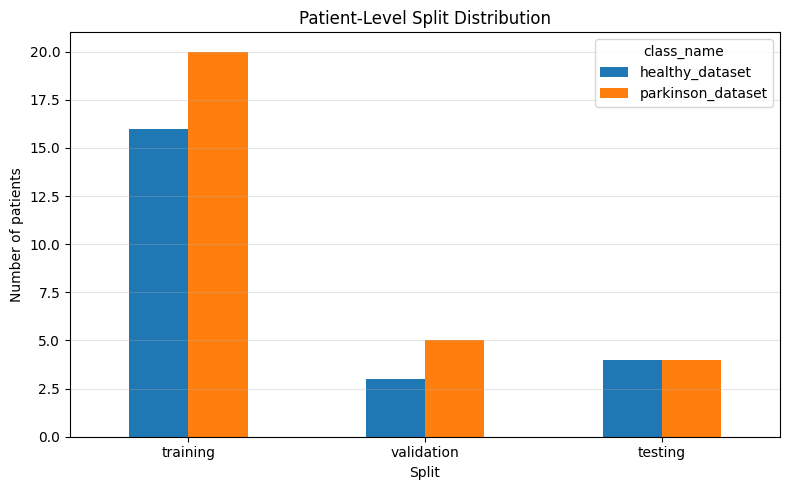

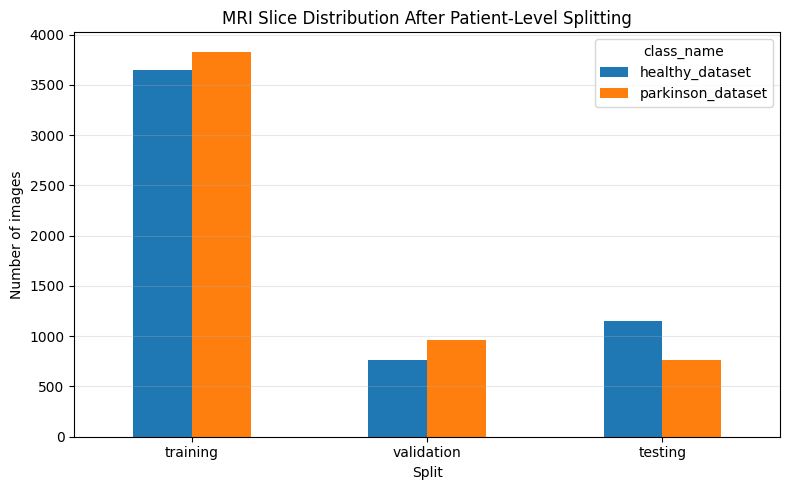

In [9]:
patient_plot_df = (
    split_summary.pivot(
        index="split",
        columns="class_name",
        values="patients",
    )
    .loc[["training", "validation", "testing"]]
)

plt.figure(figsize=(8, 5))
patient_plot_df.plot(kind="bar", ax=plt.gca())
plt.title("Patient-Level Split Distribution")
plt.xlabel("Split")
plt.ylabel("Number of patients")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
patient_split_graph = GRAPH_DIR / "patient_split_distribution.png"
plt.savefig(patient_split_graph, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


image_plot_df = (
    split_summary.pivot(
        index="split",
        columns="class_name",
        values="images",
    )
    .loc[["training", "validation", "testing"]]
)

plt.figure(figsize=(8, 5))
image_plot_df.plot(kind="bar", ax=plt.gca())
plt.title("MRI Slice Distribution After Patient-Level Splitting")
plt.xlabel("Split")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
image_split_graph = GRAPH_DIR / "image_split_distribution.png"
plt.savefig(image_split_graph, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 10. Build the DenseNet121 `tf.data` input pipeline

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

augmentation_layers = [
    layers.RandomRotation(
        factor=0.04,
        fill_mode="nearest",
        seed=SEED,
    ),
    layers.RandomZoom(
        height_factor=(-0.10, 0.10),
        width_factor=(-0.10, 0.10),
        fill_mode="nearest",
        seed=SEED,
    ),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode="nearest",
        seed=SEED,
    ),
]

if USE_HORIZONTAL_FLIP:
    augmentation_layers.insert(
        0,
        layers.RandomFlip(
            mode="horizontal",
            seed=SEED,
        ),
    )

data_augmentation = keras.Sequential(
    augmentation_layers,
    name="mri_augmentation",
)


def decode_resize_image(filepath, label):
    image_bytes = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE,
        antialias=True,
    )
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def augment_and_preprocess(image, label):
    image = data_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label


def preprocess_only(image, label):
    image = preprocess_input(image)
    return image, label


def make_dataset(dataframe, training=False):
    filepaths = dataframe["filepath"].astype(str).to_numpy()
    labels = dataframe["label"].astype(np.float32).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    options = tf.data.Options()
    options.experimental_deterministic = not training
    dataset = dataset.with_options(options)

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        decode_resize_image,
        num_parallel_calls=AUTOTUNE,
    )

    if training:
        dataset = dataset.map(
            augment_and_preprocess,
            num_parallel_calls=AUTOTUNE,
        )
    else:
        dataset = dataset.map(
            preprocess_only,
            num_parallel_calls=AUTOTUNE,
        )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False,
    )
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, training=True)
validation_ds = make_dataset(validation_df, training=False)
test_ds = make_dataset(test_df, training=False)

sample_images, sample_labels = next(iter(train_ds))

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print(
    "Preprocessed range:",
    float(tf.reduce_min(sample_images)),
    "to",
    float(tf.reduce_max(sample_images)),
)

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Preprocessed range: -2.1179039478302 to 2.2669527530670166


In [11]:
# Optional image-level class weights using training images only.

class_weight = None

if USE_CLASS_WEIGHTS:
    training_counts = (
        train_df["label"]
        .value_counts()
        .sort_index()
    )

    training_total = len(train_df)
    number_of_classes = len(training_counts)

    class_weight = {
        int(label): float(
            training_total
            / (number_of_classes * count)
        )
        for label, count in training_counts.items()
    }

print("Class weight:", class_weight)

Class weight: None


## 11. Define DenseNet121, callbacks, graphs, and evaluation functions

In [12]:
def build_densenet121_model(
    base_trainable,
    learning_rate,
    model_name,
):
    inputs = keras.Input(
        shape=(*IMG_SIZE, 3),
        name="preprocessed_mri",
    )

    base_model = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3),
    )
    base_model.trainable = base_trainable

    # Do not hard-code training=True or training=False here.
    # Keras automatically uses training mode during fit and inference
    # mode during predict. This is important for DenseNet BatchNorm layers.
    x = base_model(inputs)

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="dense_256",
    )(x)
    x = layers.BatchNormalization(
        name="head_batch_normalization_1"
    )(x)
    x = layers.Dropout(
        0.50,
        name="dropout_1",
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        name="dense_128",
    )(x)
    x = layers.BatchNormalization(
        name="head_batch_normalization_2"
    )(x)
    x = layers.Dropout(
        0.30,
        name="dropout_2",
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="parkinson_probability",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=model_name,
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )

    return model


def save_model_summary(model, run_name):
    summary_lines = []

    model.summary(
        print_fn=lambda line: summary_lines.append(line)
    )

    summary_path = (
        REPORT_DIR / f"{run_name}_model_summary.txt"
    )
    summary_path.write_text(
        "\n".join(summary_lines),
        encoding="utf-8",
    )

    print("\n".join(summary_lines))
    print("Saved model summary:", summary_path)


def make_callbacks(run_name):
    best_model_path = (
        MODEL_DIR / f"{run_name}_best.keras"
    )

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(best_model_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=7,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.2,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            filename=str(
                HISTORY_DIR
                / f"{run_name}_epoch_log.csv"
            ),
            append=False,
        ),
        keras.callbacks.TerminateOnNaN(),
    ]

    return callbacks, best_model_path


def save_and_plot_history(history, run_name):
    history_df = pd.DataFrame(history.history)
    history_df.index = np.arange(1, len(history_df) + 1)
    history_df.index.name = "epoch"

    history_csv_path = (
        HISTORY_DIR / f"{run_name}_history.csv"
    )
    history_json_path = (
        HISTORY_DIR / f"{run_name}_history.json"
    )

    history_df.to_csv(history_csv_path)

    with open(
        history_json_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                key: [float(value) for value in values]
                for key, values in history.history.items()
            },
            file,
            indent=2,
        )

    graph_pairs = [
        ("accuracy", "val_accuracy", "Accuracy"),
        ("loss", "val_loss", "Loss"),
        ("auc", "val_auc", "AUC"),
        ("precision", "val_precision", "Precision"),
        ("recall", "val_recall", "Recall"),
    ]

    epochs = history_df.index.to_numpy()

    for train_key, validation_key, display_name in graph_pairs:
        if (
            train_key not in history_df.columns
            or validation_key not in history_df.columns
        ):
            continue

        plt.figure(figsize=(8, 5))
        plt.plot(
            epochs,
            history_df[train_key],
            marker="o",
            label=f"Training {display_name}",
        )
        plt.plot(
            epochs,
            history_df[validation_key],
            marker="o",
            label=f"Validation {display_name}",
        )
        plt.title(
            f"{run_name}\n{display_name} versus Epoch"
        )
        plt.xlabel("Epoch")
        plt.ylabel(display_name)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()

        graph_path = (
            GRAPH_DIR
            / f"{run_name}_{train_key}_vs_epoch.png"
        )

        plt.savefig(
            graph_path,
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()
        plt.close()

        print("Saved graph:", graph_path)

    return history_df


def aggregate_patient_predictions(image_predictions):
    grouped = image_predictions.groupby(
        "patient_id",
        as_index=False,
    )

    if PATIENT_AGGREGATION == "mean":
        patient_predictions = grouped.agg(
            y_true=("label", "first"),
            y_score=("y_score", "mean"),
            number_of_images=("filepath", "size"),
        )
    elif PATIENT_AGGREGATION == "median":
        patient_predictions = grouped.agg(
            y_true=("label", "first"),
            y_score=("y_score", "median"),
            number_of_images=("filepath", "size"),
        )
    elif PATIENT_AGGREGATION == "max":
        patient_predictions = grouped.agg(
            y_true=("label", "first"),
            y_score=("y_score", "max"),
            number_of_images=("filepath", "size"),
        )
    else:
        raise ValueError(
            "PATIENT_AGGREGATION must be mean, median, or max."
        )

    return patient_predictions


def calculate_binary_metrics(
    y_true,
    y_score,
    threshold,
):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )
    tn, fp, fn, tp = cm.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )
    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0.0
    )

    metrics = {
        "accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "recall_sensitivity": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "specificity": float(specificity),
        "negative_predictive_value": float(
            negative_predictive_value
        ),
        "f1_score": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "matthews_correlation_coefficient": float(
            matthews_corrcoef(
                y_true,
                y_pred,
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_true,
                y_score,
            )
        ),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "decision_threshold": float(threshold),
    }

    return metrics, y_pred, cm


def evaluate_model_at_patient_level(
    model,
    run_name,
    roc_filename,
):
    y_score_image = (
        model.predict(
            test_ds,
            verbose=1,
        )
        .reshape(-1)
    )

    if len(y_score_image) != len(test_df):
        raise RuntimeError(
            "Prediction count does not match test image count."
        )

    image_predictions = test_df[
        [
            "filepath",
            "filename",
            "patient_id",
            "label",
            "class_name",
        ]
    ].copy()

    image_predictions["y_score"] = y_score_image
    image_predictions["y_pred"] = (
        y_score_image >= DECISION_THRESHOLD
    ).astype(int)

    image_prediction_path = (
        PREDICTION_DIR
        / f"{run_name}_slice_predictions.csv"
    )
    image_predictions.to_csv(
        image_prediction_path,
        index=False,
    )


    patient_predictions = aggregate_patient_predictions(
        image_predictions
    )

    patient_metrics, patient_y_pred, cm = (
        calculate_binary_metrics(
            patient_predictions["y_true"],
            patient_predictions["y_score"],
            DECISION_THRESHOLD,
        )
    )

    patient_predictions["y_pred"] = patient_y_pred
    patient_predictions["true_class"] = (
        patient_predictions["y_true"].map(
            {
                0: "healthy_dataset",
                1: "parkinson_dataset",
            }
        )
    )
    patient_predictions["predicted_class"] = (
        patient_predictions["y_pred"].map(
            {
                0: "healthy_dataset",
                1: "parkinson_dataset",
            }
        )
    )

    patient_prediction_path = (
        PREDICTION_DIR
        / f"{run_name}_patient_predictions.csv"
    )
    patient_predictions.to_csv(
        patient_prediction_path,
        index=False,
    )


    y_true = patient_predictions[
        "y_true"
    ].astype(int).to_numpy()

    y_score = patient_predictions[
        "y_score"
    ].astype(float).to_numpy()

    y_pred = patient_predictions[
        "y_pred"
    ].astype(int).to_numpy()


    fpr, tpr, roc_thresholds = roc_curve(
        y_true,
        y_score,
    )


    patient_metrics.update(
        {
            "model": run_name,
            "evaluation_level": "patient",
            "aggregation": PATIENT_AGGREGATION,
            "number_of_test_patients": int(
                len(patient_predictions)
            ),
            "number_of_test_images": int(
                len(image_predictions)
            ),
        }
    )


    metrics_json_path = (
        REPORT_DIR
        / f"{run_name}_patient_metrics.json"
    )

    with open(
        metrics_json_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            patient_metrics,
            file,
            indent=2,
        )


    metrics_csv_path = (
        REPORT_DIR
        / f"{run_name}_patient_metrics.csv"
    )

    pd.DataFrame(
        [patient_metrics]
    ).to_csv(
        metrics_csv_path,
        index=False,
    )


    report_text = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=[
            "Healthy",
            "Parkinson",
        ],
        digits=4,
        zero_division=0,
    )

    report_path = (
        REPORT_DIR
        / f"{run_name}_classification_report.txt"
    )

    with open(
        report_path,
        "w",
        encoding="utf-8",
    ) as file:
        file.write(
            "PATIENT-LEVEL EVALUATION\n"
        )
        file.write(
            "========================\n\n"
        )

        for metric_name, metric_value in patient_metrics.items():
            file.write(
                f"{metric_name}: {metric_value}\n"
            )

        file.write(
            "\nClassification report:\n"
        )
        file.write(report_text)


    cm_df = pd.DataFrame(
        cm,
        index=[
            "Actual Healthy",
            "Actual Parkinson",
        ],
        columns=[
            "Predicted Healthy",
            "Predicted Parkinson",
        ],
    )

    cm_csv_path = (
        CM_DIR
        / f"{run_name}_patient_confusion_matrix.csv"
    )
    cm_df.to_csv(cm_csv_path)


    plt.figure(figsize=(6, 6))
    display_object = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Healthy",
            "Parkinson",
        ],
    )
    display_object.plot(
        ax=plt.gca(),
        values_format="d",
    )
    plt.title(
        f"{run_name}\nPatient-Level Confusion Matrix"
    )
    plt.tight_layout()

    cm_png_path = (
        CM_DIR
        / f"{run_name}_patient_confusion_matrix.png"
    )

    plt.savefig(
        cm_png_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()


    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"Patient ROC "
            f"(AUC = {patient_metrics['roc_auc']:.4f})"
        ),
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Chance",
    )
    plt.title(
        f"{run_name}\nPatient-Level ROC Curve"
    )
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_graph_path = (
        GRAPH_DIR
        / f"{run_name}_patient_roc.png"
    )

    plt.savefig(
        roc_graph_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()


    roc_npz_path = ROC_DIR / roc_filename

    np.savez_compressed(
        roc_npz_path,
        patient_ids=patient_predictions[
            "patient_id"
        ].astype(str).to_numpy(dtype="U"),
        y_true=y_true.astype(np.int64),
        y_score=y_score.astype(np.float64),
        y_pred=y_pred.astype(np.int64),
        fpr=fpr.astype(np.float64),
        tpr=tpr.astype(np.float64),
        thresholds=roc_thresholds.astype(np.float64),
        auc=np.asarray(
            patient_metrics["roc_auc"],
            dtype=np.float64,
        ),
        decision_threshold=np.asarray(
            DECISION_THRESHOLD,
            dtype=np.float64,
        ),
        aggregation=np.asarray(
            PATIENT_AGGREGATION
        ),
        evaluation_level=np.asarray(
            "patient"
        ),
        positive_class=np.asarray(
            "parkinson_dataset"
        ),
        negative_class=np.asarray(
            "healthy_dataset"
        ),
        model_name=np.asarray(run_name),
        number_of_images=patient_predictions[
            "number_of_images"
        ].to_numpy(dtype=np.int64),
    )


    print("\nPATIENT-LEVEL CLASSIFICATION REPORT")
    print(report_text)

    print("\nPATIENT-LEVEL METRICS")
    for metric_name, metric_value in patient_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nSaved ROC NPZ:", roc_npz_path)


    return {
        "metrics": patient_metrics,
        "patient_predictions": patient_predictions,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": roc_thresholds,
        "roc_npz_path": str(roc_npz_path),
    }


def format_runtime(seconds):
    hours = int(seconds // 3600)
    minutes = int(
        (seconds % 3600) // 60
    )
    remaining_seconds = int(seconds % 60)

    return (
        f"{hours} hours "
        f"{minutes} minutes "
        f"{remaining_seconds} seconds"
    )


def run_experiment(
    run_name,
    base_trainable,
    learning_rate,
    epochs,
    roc_filename,
):
    tf.keras.backend.clear_session()
    gc.collect()

    model = build_densenet121_model(
        base_trainable=base_trainable,
        learning_rate=learning_rate,
        model_name=run_name,
    )

    save_model_summary(
        model,
        run_name,
    )

    callbacks, best_model_path = make_callbacks(
        run_name
    )

    training_start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1,
    )

    runtime_seconds = (
        time.time() - training_start_time
    )
    runtime_text = format_runtime(
        runtime_seconds
    )

    print(
        f"{run_name} runtime:",
        runtime_text,
    )

    # The best model is already saved by ModelCheckpoint.
    # Save the restored final in-memory model too.
    final_model_path = (
        MODEL_DIR / f"{run_name}_final.keras"
    )
    model.save(final_model_path)

    history_df = save_and_plot_history(
        history,
        run_name,
    )

    evaluation = evaluate_model_at_patient_level(
        model=model,
        run_name=run_name,
        roc_filename=roc_filename,
    )

    evaluation["metrics"]["runtime_seconds"] = float(
        runtime_seconds
    )
    evaluation["metrics"]["runtime"] = runtime_text
    evaluation["metrics"]["base_trainable"] = bool(
        base_trainable
    )
    evaluation["metrics"]["include_top"] = False
    evaluation["metrics"]["learning_rate"] = float(
        learning_rate
    )
    evaluation["metrics"]["epochs_completed"] = int(
        len(history_df)
    )

    updated_metrics_path = (
        REPORT_DIR
        / f"{run_name}_patient_metrics.json"
    )

    with open(
        updated_metrics_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            evaluation["metrics"],
            file,
            indent=2,
        )

    pd.DataFrame(
        [evaluation["metrics"]]
    ).to_csv(
        REPORT_DIR
        / f"{run_name}_patient_metrics.csv",
        index=False,
    )

    result = {
        "run_name": run_name,
        "metrics": evaluation["metrics"],
        "fpr": evaluation["fpr"],
        "tpr": evaluation["tpr"],
        "thresholds": evaluation["thresholds"],
        "roc_npz_path": evaluation["roc_npz_path"],
        "history": history_df,
        "best_model_path": str(best_model_path),
        "final_model_path": str(final_model_path),
    }

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return result

## 12. Train DenseNet121 with `base_model.trainable=False`

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "DenseNet121_include_top_false_base_trainable_false_patient_level"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessed_mri (InputLayer)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 

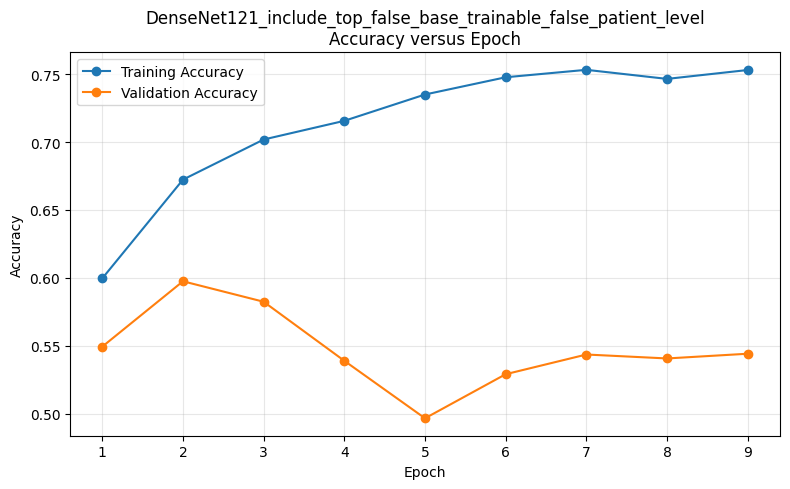

Saved graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/DenseNet121_include_top_false_base_trainable_false_patient_level_accuracy_vs_epoch.png


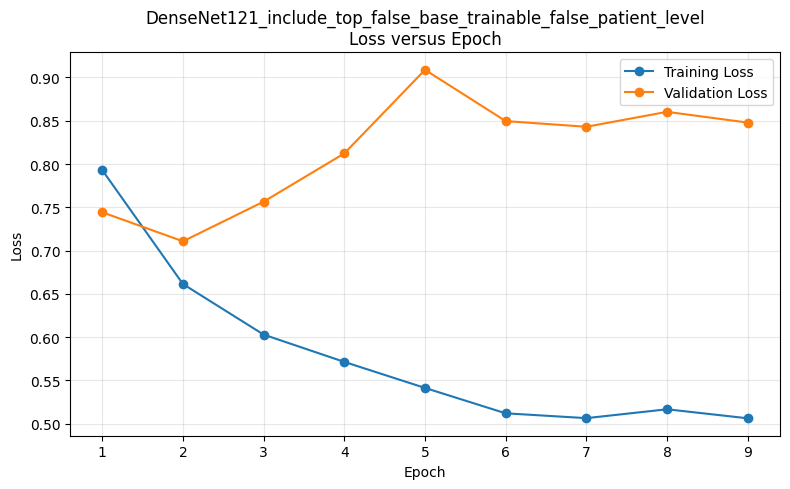

Saved graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/DenseNet121_include_top_false_base_trainable_false_patient_level_loss_vs_epoch.png


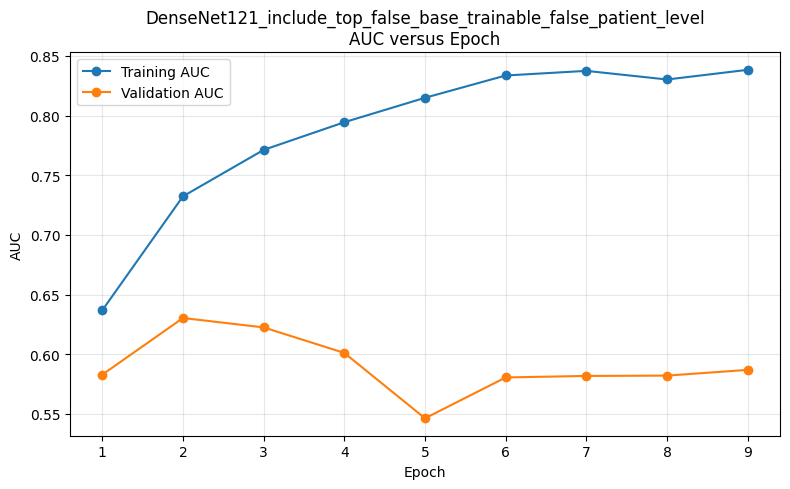

Saved graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/DenseNet121_include_top_false_base_trainable_false_patient_level_auc_vs_epoch.png


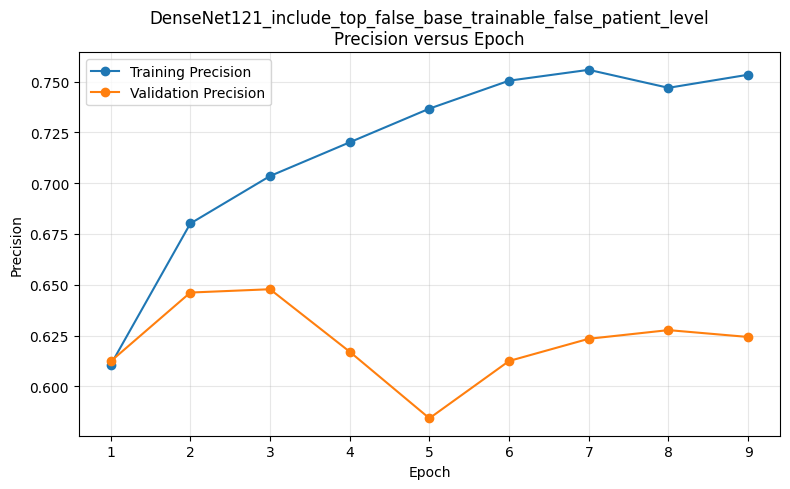

Saved graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/DenseNet121_include_top_false_base_trainable_false_patient_level_precision_vs_epoch.png


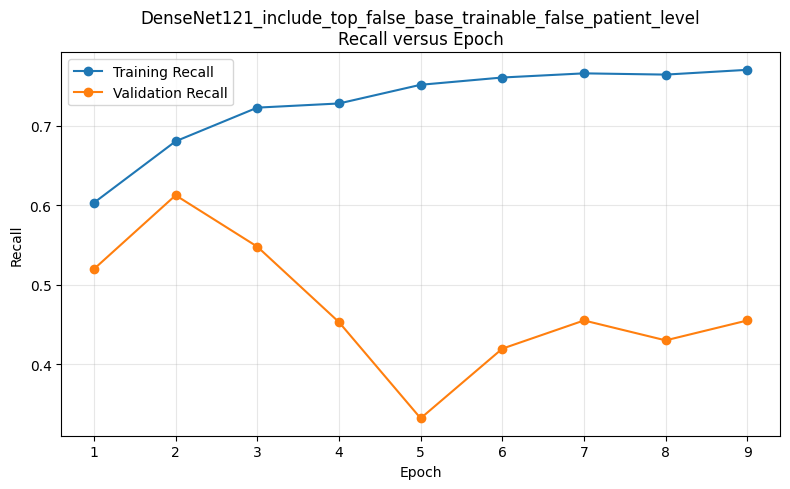

Saved graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/DenseNet121_include_top_false_base_trainable_false_patient_level_recall_vs_epoch.png
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 130ms/step


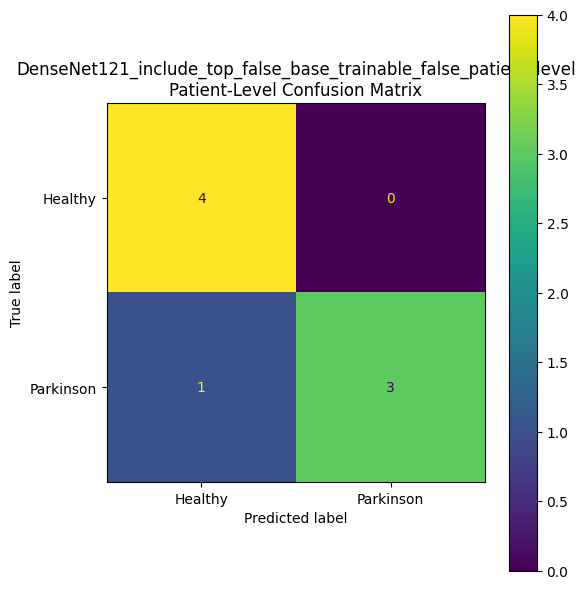

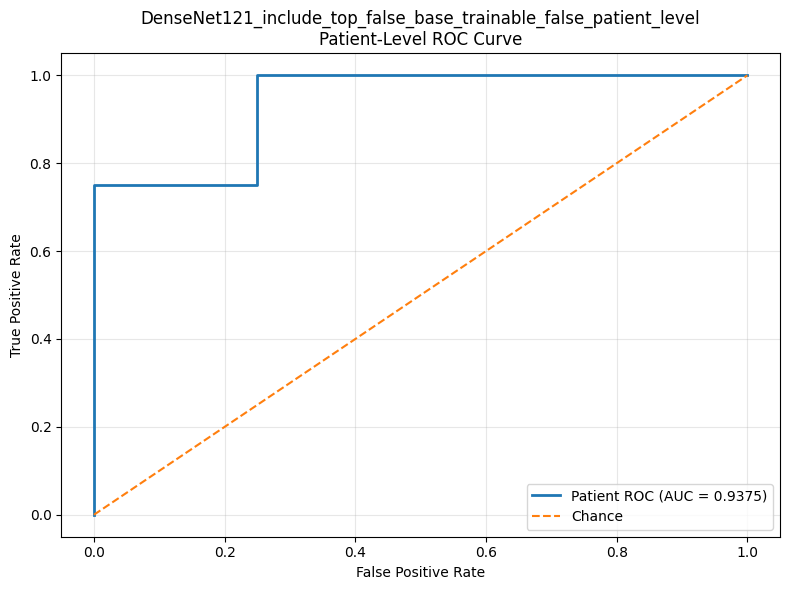


PATIENT-LEVEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy     0.8000    1.0000    0.8889         4
   Parkinson     1.0000    0.7500    0.8571         4

    accuracy                         0.8750         8
   macro avg     0.9000    0.8750    0.8730         8
weighted avg     0.9000    0.8750    0.8730         8


PATIENT-LEVEL METRICS
accuracy: 0.875
precision: 1.0
recall_sensitivity: 0.75
specificity: 1.0
negative_predictive_value: 0.8
f1_score: 0.8571428571428571
balanced_accuracy: 0.875
matthews_correlation_coefficient: 0.7745966692414834
roc_auc: 0.9375
true_negative: 4
false_positive: 0
false_negative: 1
true_positive: 3
decision_threshold: 0.5
model: DenseNet121_include_top_false_base_trainable_false_patient_level
evaluation_level: patient
aggregation: mean
number_of_test_patients: 8
number_of_test_images: 1916

Saved ROC NPZ: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/roc_npz/densenet

In [13]:
FROZEN_RUN_NAME = (
    "DenseNet121_include_top_false_"
    "base_trainable_false_patient_level"
)

frozen_result = run_experiment(
    run_name=FROZEN_RUN_NAME,
    base_trainable=False,
    learning_rate=LEARNING_RATE_FROZEN,
    epochs=EPOCHS_FROZEN,
    roc_filename=(
        "densenet121_base_frozen_"
        "patient_level_roc.npz"
    ),
)

## 13. Train DenseNet121 with `base_model.trainable=True`

Model: "DenseNet121_include_top_false_base_trainable_true_patient_level"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessed_mri (InputLayer)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h

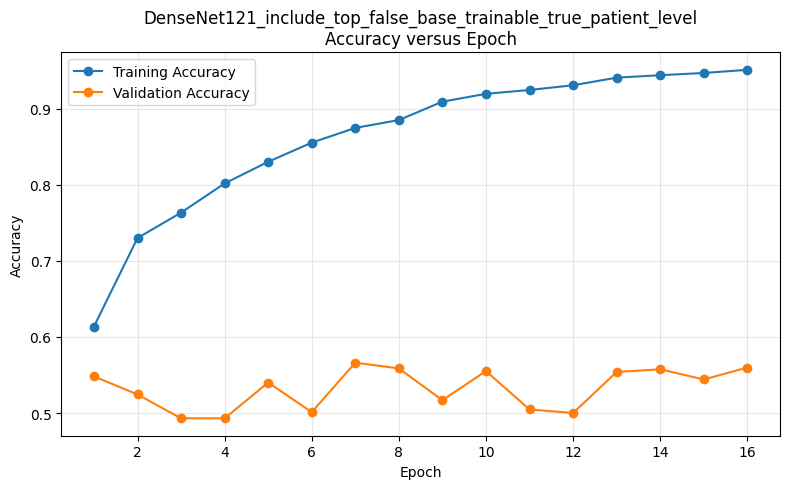

Saved graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/DenseNet121_include_top_false_base_trainable_true_patient_level_accuracy_vs_epoch.png


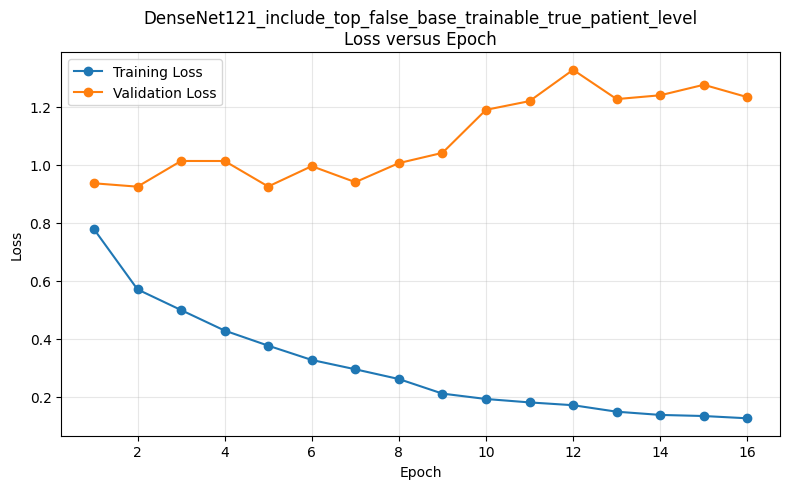

Saved graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/DenseNet121_include_top_false_base_trainable_true_patient_level_loss_vs_epoch.png


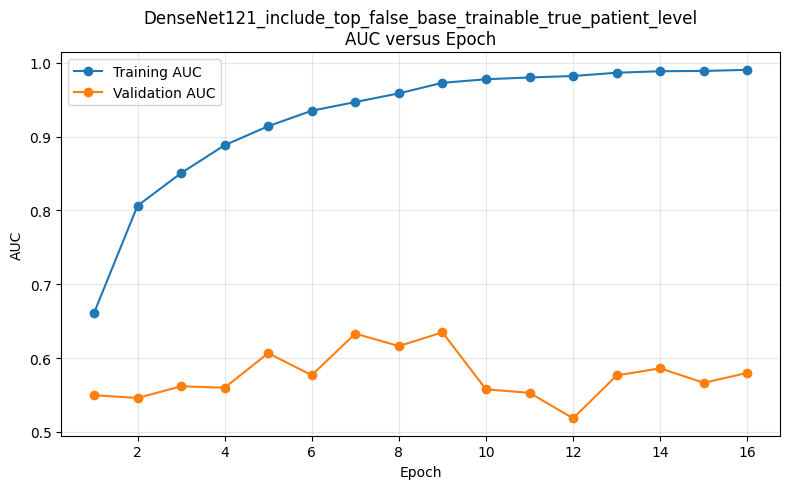

Saved graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/DenseNet121_include_top_false_base_trainable_true_patient_level_auc_vs_epoch.png


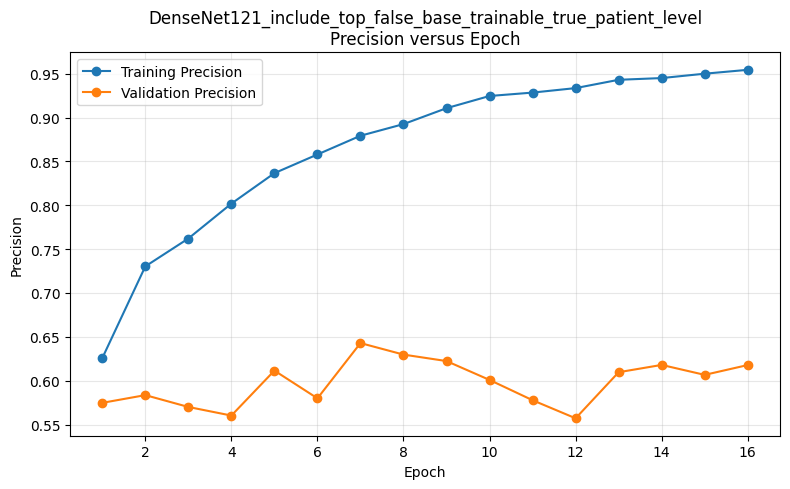

Saved graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/DenseNet121_include_top_false_base_trainable_true_patient_level_precision_vs_epoch.png


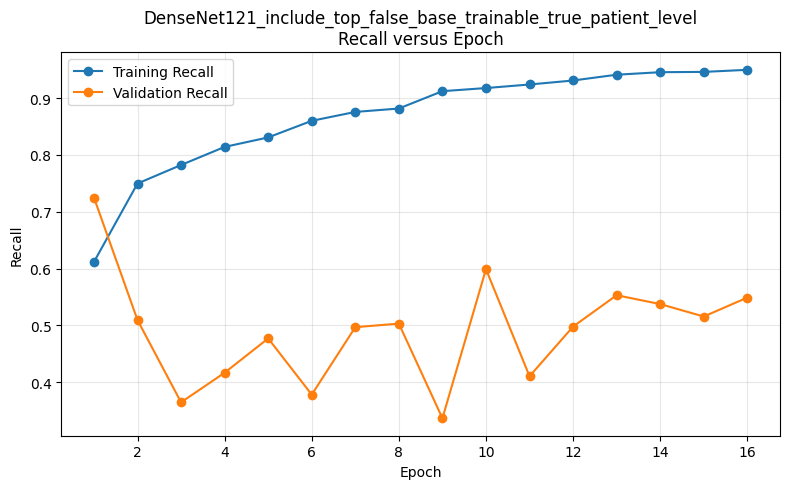

Saved graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/DenseNet121_include_top_false_base_trainable_true_patient_level_recall_vs_epoch.png
120/120 ━━━━━━━━━━━━━━━━━━━━ 29s 133ms/step


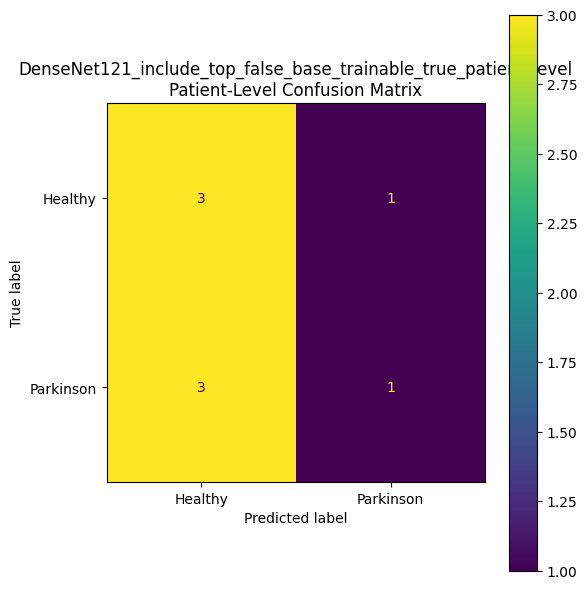

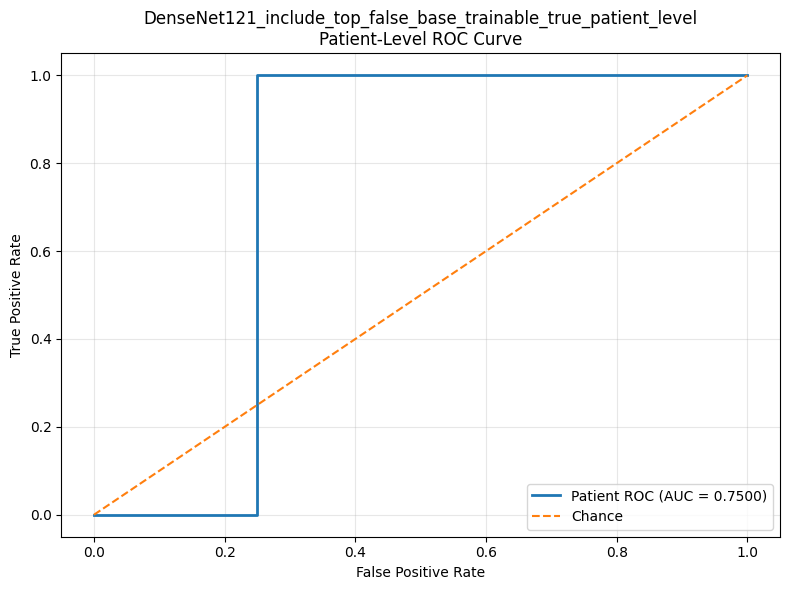


PATIENT-LEVEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy     0.5000    0.7500    0.6000         4
   Parkinson     0.5000    0.2500    0.3333         4

    accuracy                         0.5000         8
   macro avg     0.5000    0.5000    0.4667         8
weighted avg     0.5000    0.5000    0.4667         8


PATIENT-LEVEL METRICS
accuracy: 0.5
precision: 0.5
recall_sensitivity: 0.25
specificity: 0.75
negative_predictive_value: 0.5
f1_score: 0.3333333333333333
balanced_accuracy: 0.5
matthews_correlation_coefficient: 0.0
roc_auc: 0.75
true_negative: 3
false_positive: 1
false_negative: 3
true_positive: 1
decision_threshold: 0.5
model: DenseNet121_include_top_false_base_trainable_true_patient_level
evaluation_level: patient
aggregation: mean
number_of_test_patients: 8
number_of_test_images: 1916

Saved ROC NPZ: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/roc_npz/densenet121_base_trainable_pa

In [14]:
TRAINABLE_RUN_NAME = (
    "DenseNet121_include_top_false_"
    "base_trainable_true_patient_level"
)

trainable_result = run_experiment(
    run_name=TRAINABLE_RUN_NAME,
    base_trainable=True,
    learning_rate=LEARNING_RATE_TRAINABLE,
    epochs=EPOCHS_TRAINABLE,
    roc_filename=(
        "densenet121_base_trainable_"
        "patient_level_roc.npz"
    ),
)

## Grad-CAM for both DenseNet121 patient-level models

GRAD-CAM TEST SAMPLES


,patient_id,label,class_name,filename
0,113447,0,healthy_dataset,PPMI_113447_MR_SAG_3D_T1-weighted_br_raw_20220...
1,130190,0,healthy_dataset,PPMI_130190_MR_3D_T1_MPRAGE_br_raw_20220225013...
2,101179,1,parkinson_dataset,PPMI_101179_MR_3D_T1-weighted_br_raw_202109162...
3,101295,1,parkinson_dataset,"PPMI_101295_MR_T1-weighted,_3D_VOLUMETRIC_br_r..."



Loading Grad-CAM model: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/models/DenseNet121_include_top_false_base_trainable_false_patient_level_best.keras


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['preprocessed_mri']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


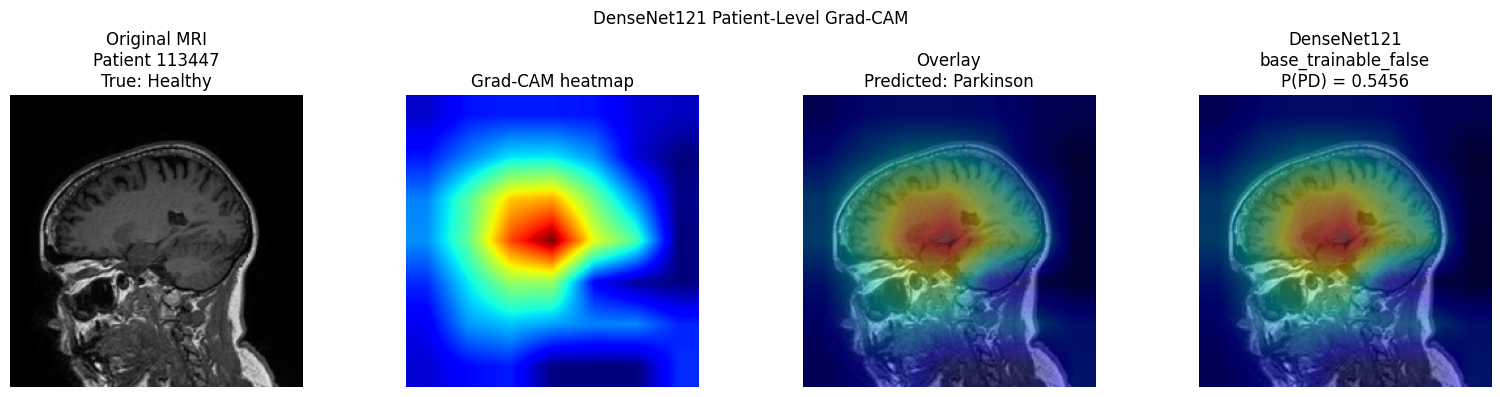

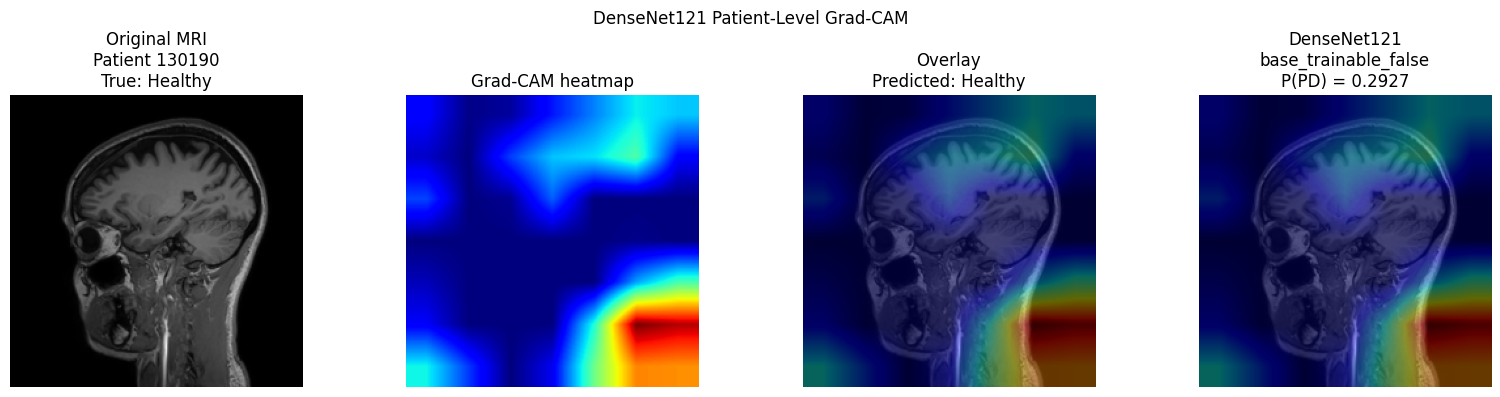

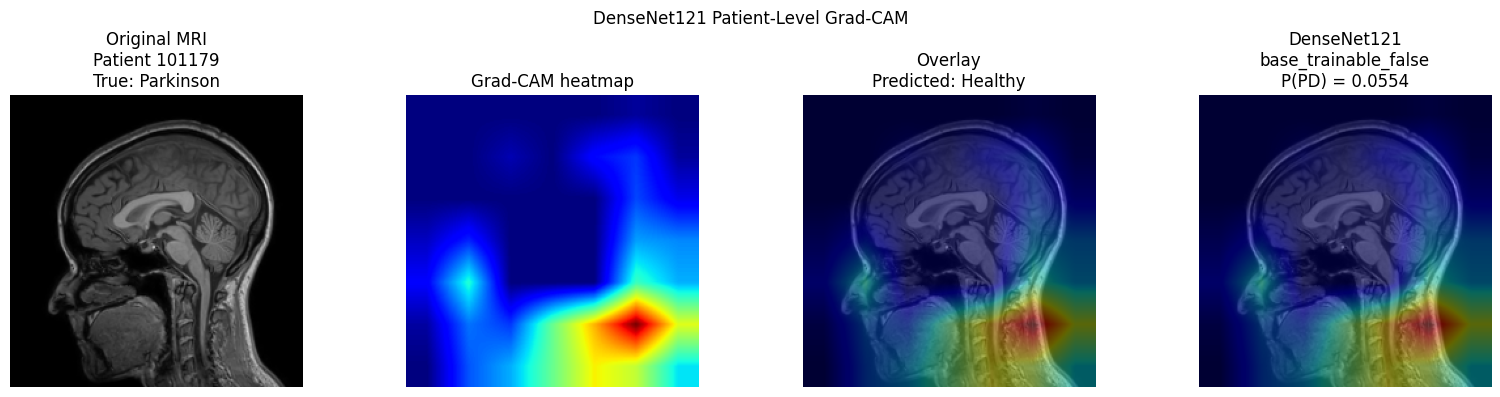

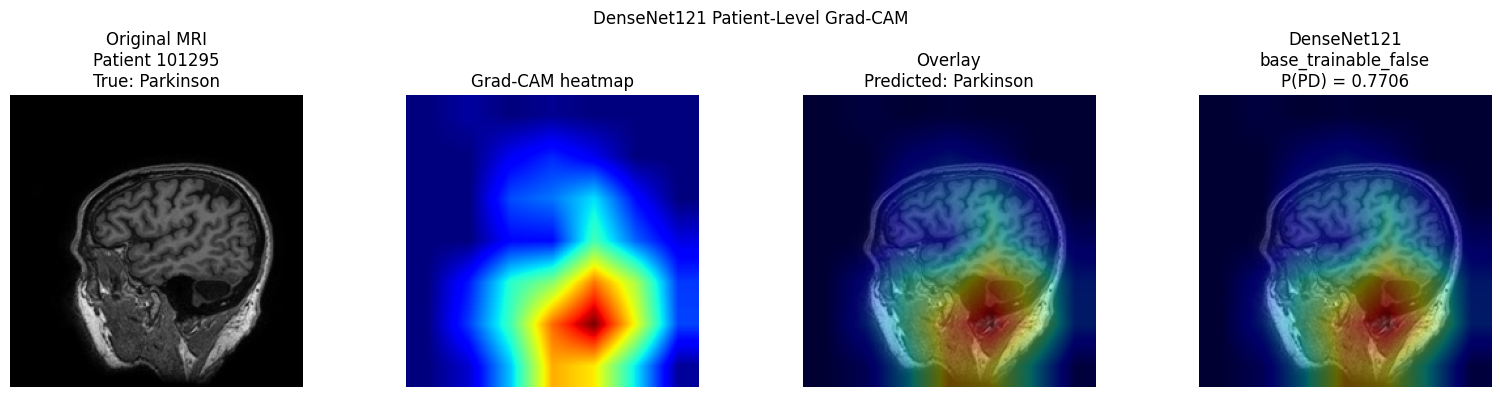


Loading Grad-CAM model: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/models/DenseNet121_include_top_false_base_trainable_true_patient_level_best.keras


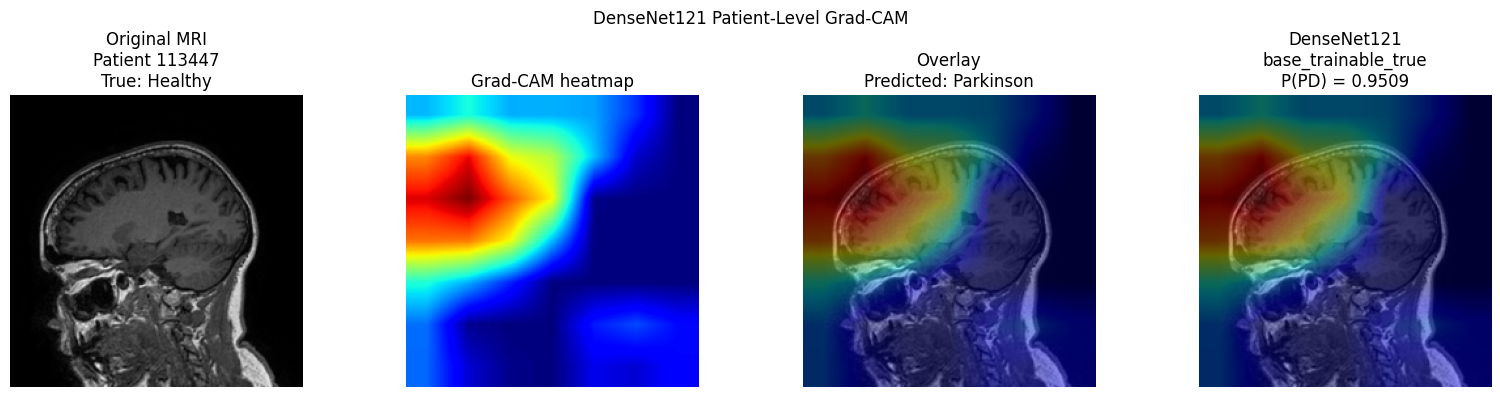

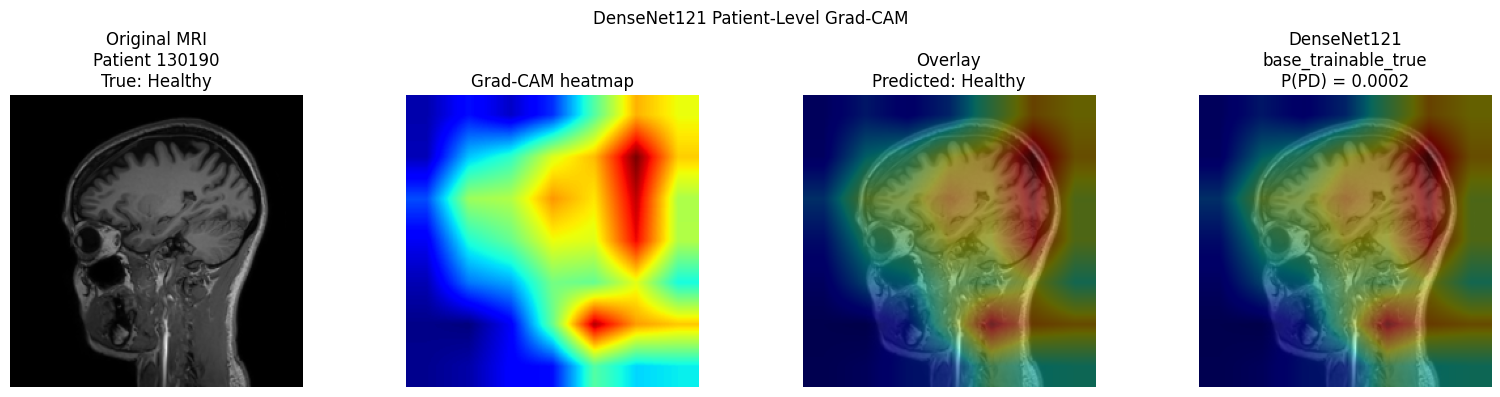

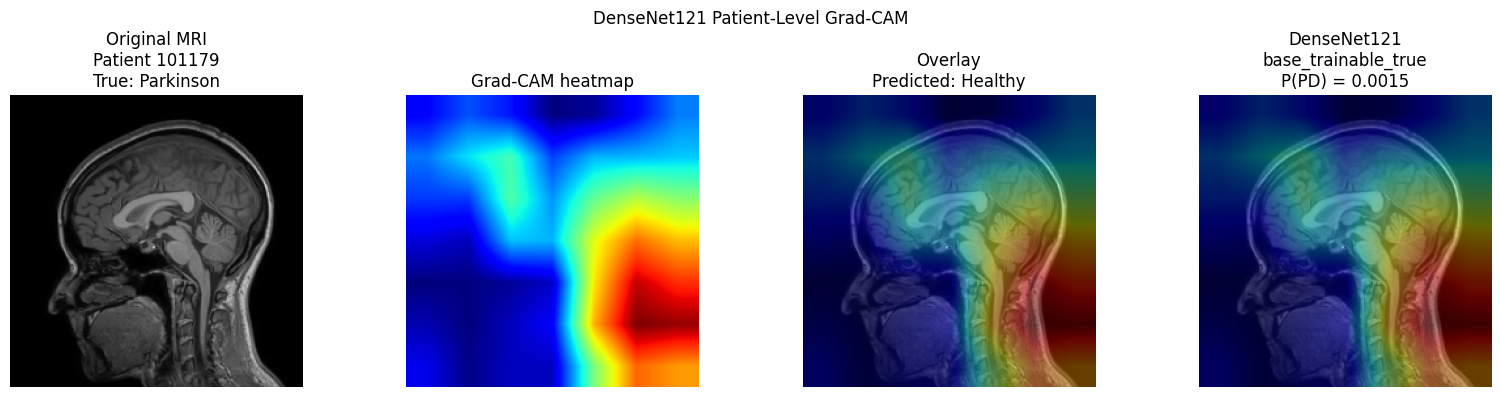

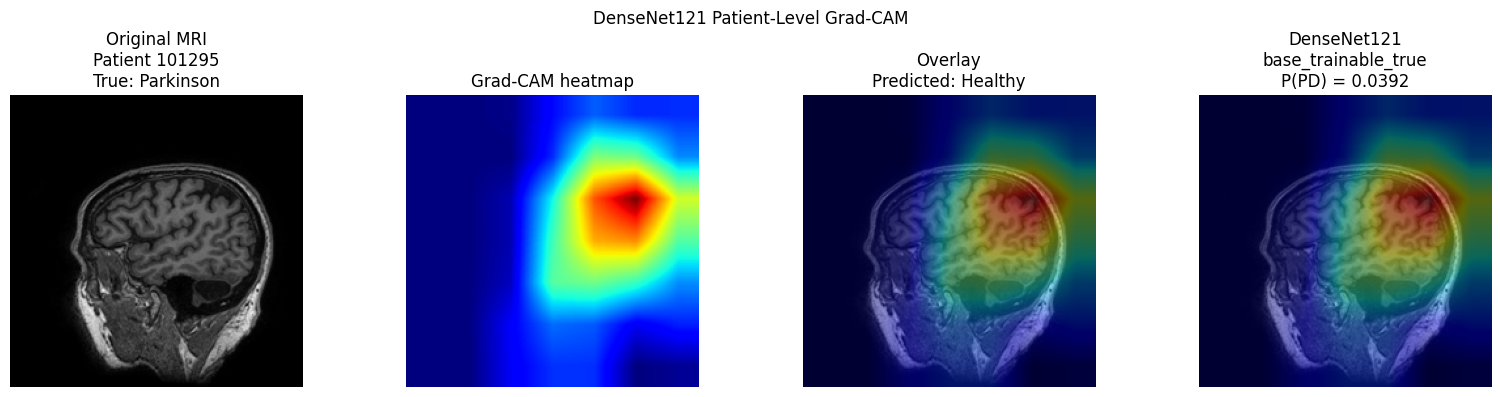

,architecture,model_variant,patient_id,true_label,predicted_label,parkinson_probability,image_path,gradcam_png,gradcam_npz
0,DenseNet121,base_trainable_false,113447,Healthy,Parkinson,0.545599,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
1,DenseNet121,base_trainable_false,130190,Healthy,Healthy,0.292705,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
2,DenseNet121,base_trainable_false,101179,Parkinson,Healthy,0.055357,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
3,DenseNet121,base_trainable_false,101295,Parkinson,Parkinson,0.770608,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
4,DenseNet121,base_trainable_true,113447,Healthy,Parkinson,0.950888,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
5,DenseNet121,base_trainable_true,130190,Healthy,Healthy,0.000184,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
6,DenseNet121,base_trainable_true,101179,Parkinson,Healthy,0.001541,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...
7,DenseNet121,base_trainable_true,101295,Parkinson,Healthy,0.039157,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...


Saved Grad-CAM manifest: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/gradcam/densenet121_gradcam_manifest.csv
Grad-CAM PNG and NPZ verification passed for 8 files.


In [15]:
# ============================================================
# GRAD-CAM FOR FROZEN AND TRAINABLE DenseNet121 MODELS
# ============================================================

GRADCAM_PATIENTS_PER_CLASS = 2
GRADCAM_ALPHA = 0.40


def extract_slice_number_for_gradcam(filename):
    match = re.search(
        r"slice_(\d+)",
        str(filename),
        flags=re.IGNORECASE,
    )
    return int(match.group(1)) if match else 0


def select_gradcam_test_samples(
    dataframe,
    patients_per_class=2,
):
    """
    Select one middle MRI slice from several healthy and Parkinson
    patients. Only the patient-level TEST set is used.
    """
    selected_rows = []

    for label in [0, 1]:
        patient_ids = list(
            dataframe.loc[
                dataframe["label"] == label,
                "patient_id",
            ].astype(str).unique()
        )

        patient_ids = sorted(
            patient_ids,
            key=lambda value: int(value),
        )[:patients_per_class]

        for patient_id in patient_ids:
            patient_images = dataframe[
                dataframe["patient_id"].astype(str)
                == str(patient_id)
            ].copy()

            patient_images["slice_number"] = (
                patient_images["filename"].map(
                    extract_slice_number_for_gradcam
                )
            )

            patient_images = patient_images.sort_values(
                ["slice_number", "filename"]
            ).reset_index(drop=True)

            middle_index = len(patient_images) // 2
            selected_rows.append(
                patient_images.iloc[middle_index]
            )

    if not selected_rows:
        raise ValueError(
            "No Grad-CAM test samples were selected."
        )

    return pd.DataFrame(selected_rows).reset_index(
        drop=True
    )


def normalize_gradcam_heatmap(heatmap):
    heatmap = np.maximum(heatmap, 0)
    maximum = np.max(heatmap)

    if maximum <= 0:
        return np.zeros_like(
            heatmap,
            dtype=np.float32,
        )

    return (
        heatmap / maximum
    ).astype(np.float32)


def compute_model_gradcam(
    model,
    preprocessed_batch,
    target_class=None,
):
    """
    Use the tensor entering GlobalAveragePooling2D. This is the final
    convolutional feature map from the pretrained backbone.
    """
    gap_layer = model.get_layer(
        "global_average_pooling"
    )
    convolutional_tensor = gap_layer.input

    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[
            convolutional_tensor,
            model.output,
        ],
    )

    with tf.GradientTape() as tape:
        feature_maps, predictions = grad_model(
            preprocessed_batch,
            training=False,
        )

        positive_probability = predictions[:, 0]

        if target_class is None:
            target_class = int(
                positive_probability[0] >= 0.50
            )

        if int(target_class) == 1:
            class_score = positive_probability
        else:
            class_score = 1.0 - positive_probability

    gradients = tape.gradient(
        class_score,
        feature_maps,
    )

    if gradients is None:
        raise RuntimeError(
            "Grad-CAM gradients are None."
        )

    channel_weights = tf.reduce_mean(
        gradients,
        axis=(1, 2),
    )

    weighted_maps = (
        feature_maps
        * channel_weights[:, None, None, :]
    )

    heatmap = tf.reduce_sum(
        weighted_maps,
        axis=-1,
    )[0].numpy()

    heatmap = normalize_gradcam_heatmap(
        heatmap
    )

    return (
        heatmap,
        float(positive_probability[0]),
        int(target_class),
    )


def resize_and_overlay_gradcam(
    raw_image,
    heatmap,
    alpha=0.40,
):
    resized_heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        size=raw_image.shape[:2],
        method="bilinear",
    ).numpy().squeeze()

    resized_heatmap = normalize_gradcam_heatmap(
        resized_heatmap
    )

    colored_heatmap = plt.get_cmap("jet")(
        resized_heatmap
    )[..., :3]

    normalized_image = np.clip(
        raw_image / 255.0,
        0.0,
        1.0,
    )

    overlay = np.clip(
        (1.0 - alpha) * normalized_image
        + alpha * colored_heatmap,
        0.0,
        1.0,
    )

    return (
        resized_heatmap.astype(np.float32),
        colored_heatmap.astype(np.float32),
        overlay.astype(np.float32),
    )


def save_single_gradcam(
    model,
    model_variant,
    sample_row,
):
    image_path = Path(sample_row["filepath"])
    patient_id = str(sample_row["patient_id"])
    true_class = int(sample_row["label"])
    true_label = (
        "Parkinson"
        if true_class == 1
        else "Healthy"
    )

    loaded_image = keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE,
        color_mode="rgb",
    )

    raw_image = keras.utils.img_to_array(
        loaded_image
    ).astype(np.float32)

    # Each notebook already imports the correct architecture-specific
    # preprocess_input function.
    preprocessed_batch = preprocess_input(
        np.expand_dims(
            raw_image.copy(),
            axis=0,
        )
    )

    heatmap, probability, predicted_class = (
        compute_model_gradcam(
            model=model,
            preprocessed_batch=preprocessed_batch,
            target_class=None,
        )
    )

    predicted_label = (
        "Parkinson"
        if predicted_class == 1
        else "Healthy"
    )

    resized_heatmap, colored_heatmap, overlay = (
        resize_and_overlay_gradcam(
            raw_image=raw_image,
            heatmap=heatmap,
            alpha=GRADCAM_ALPHA,
        )
    )

    variant_dir = (
        GRADCAM_DIR / model_variant
    )
    variant_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    safe_stem = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        image_path.stem,
    )

    file_prefix = (
        f"patient_{patient_id}_"
        f"true_{true_label}_"
        f"{safe_stem}"
    )

    png_path = (
        variant_dir
        / f"{file_prefix}_gradcam.png"
    )

    npz_path = (
        variant_dir
        / f"{file_prefix}_gradcam_data.npz"
    )

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(
        np.clip(
            raw_image / 255.0,
            0.0,
            1.0,
        )
    )
    plt.title(
        f"Original MRI\n"
        f"Patient {patient_id}\n"
        f"True: {true_label}"
    )
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(
        resized_heatmap,
        cmap="jet",
    )
    plt.title("Grad-CAM heatmap")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(overlay)
    plt.title(
        f"Overlay\n"
        f"Predicted: {predicted_label}"
    )
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title(
        f"DenseNet121\n"
        f"{model_variant}\n"
        f"P(PD) = {probability:.4f}"
    )
    plt.axis("off")

    plt.suptitle(
        f"DenseNet121 Patient-Level Grad-CAM"
    )
    plt.tight_layout()

    plt.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    np.savez_compressed(
        npz_path,
        heatmap=heatmap.astype(np.float32),
        resized_heatmap=resized_heatmap.astype(
            np.float32
        ),
        colored_heatmap=colored_heatmap.astype(
            np.float32
        ),
        overlay=overlay.astype(np.float32),
        image_path=np.asarray(
            str(image_path)
        ),
        filename=np.asarray(
            str(image_path.name)
        ),
        patient_id=np.asarray(patient_id),
        true_class=np.asarray(
            true_class,
            dtype=np.int32,
        ),
        true_label=np.asarray(true_label),
        predicted_class=np.asarray(
            predicted_class,
            dtype=np.int32,
        ),
        predicted_label=np.asarray(
            predicted_label
        ),
        parkinson_probability=np.asarray(
            probability,
            dtype=np.float32,
        ),
        model_variant=np.asarray(
            model_variant
        ),
        architecture=np.asarray(
            "DenseNet121"
        ),
        evaluation_split=np.asarray(
            "patient_level_test"
        ),
    )

    return {
        "architecture": "DenseNet121",
        "model_variant": model_variant,
        "patient_id": patient_id,
        "true_label": true_label,
        "predicted_label": predicted_label,
        "parkinson_probability": probability,
        "image_path": str(image_path),
        "gradcam_png": str(png_path),
        "gradcam_npz": str(npz_path),
    }


gradcam_samples = select_gradcam_test_samples(
    test_df,
    patients_per_class=GRADCAM_PATIENTS_PER_CLASS,
)

print("GRAD-CAM TEST SAMPLES")
display(
    gradcam_samples[
        [
            "patient_id",
            "label",
            "class_name",
            "filename",
        ]
    ]
)


gradcam_model_specs = [
    (
        "base_trainable_false",
        Path(frozen_result["best_model_path"]),
    ),
    (
        "base_trainable_true",
        Path(trainable_result["best_model_path"]),
    ),
]


gradcam_manifest_rows = []

for model_variant, saved_model_path in gradcam_model_specs:
    if not saved_model_path.exists():
        raise FileNotFoundError(
            f"Saved model not found: {saved_model_path}"
        )

    print(
        "\nLoading Grad-CAM model:",
        saved_model_path,
    )

    gradcam_model = keras.models.load_model(
        saved_model_path,
        compile=False,
    )

    for _, sample_row in gradcam_samples.iterrows():
        gradcam_manifest_rows.append(
            save_single_gradcam(
                model=gradcam_model,
                model_variant=model_variant,
                sample_row=sample_row,
            )
        )

    del gradcam_model
    tf.keras.backend.clear_session()
    gc.collect()


gradcam_manifest_df = pd.DataFrame(
    gradcam_manifest_rows
)

gradcam_manifest_path = (
    GRADCAM_DIR
    / "densenet121_gradcam_manifest.csv"
)

gradcam_manifest_df.to_csv(
    gradcam_manifest_path,
    index=False,
)

display(gradcam_manifest_df)

print(
    "Saved Grad-CAM manifest:",
    gradcam_manifest_path,
)


# Verify every raw Grad-CAM NPZ file.
gradcam_npz_files = sorted(
    GRADCAM_DIR.rglob(
        "*_gradcam_data.npz"
    )
)

assert len(gradcam_npz_files) > 0

gradcam_verification_rows = []

for gradcam_npz_file in gradcam_npz_files:
    with np.load(
        gradcam_npz_file,
        allow_pickle=False,
    ) as gradcam_data:
        required_keys = {
            "heatmap",
            "resized_heatmap",
            "overlay",
            "patient_id",
            "true_label",
            "predicted_label",
            "parkinson_probability",
            "model_variant",
            "architecture",
        }

        missing_keys = (
            required_keys
            - set(gradcam_data.files)
        )

        if missing_keys:
            raise KeyError(
                f"{gradcam_npz_file} is missing "
                f"keys: {sorted(missing_keys)}"
            )

        gradcam_verification_rows.append(
            {
                "file": str(gradcam_npz_file),
                "keys": ", ".join(
                    gradcam_data.files
                ),
                "heatmap_shape": str(
                    gradcam_data[
                        "heatmap"
                    ].shape
                ),
                "loads_successfully": True,
            }
        )

gradcam_verification_df = pd.DataFrame(
    gradcam_verification_rows
)

gradcam_verification_df.to_csv(
    GRADCAM_DIR
    / "densenet121_gradcam_npz_verification.csv",
    index=False,
)

print(
    "Grad-CAM PNG and NPZ verification passed for",
    len(gradcam_npz_files),
    "files.",
)

## 14. Compare all patient-level metrics

,accuracy,precision,recall_sensitivity,specificity,negative_predictive_value,f1_score,balanced_accuracy,matthews_correlation_coefficient,roc_auc,true_negative,...,evaluation_level,aggregation,number_of_test_patients,number_of_test_images,runtime_seconds,runtime,base_trainable,include_top,learning_rate,epochs_completed
0,0.875,1.0,0.75,1.00,0.8,0.857143,0.875,0.774597,0.9375,4,...,patient,mean,8,1916,328.677562,0 hours 5 minutes 28 seconds,False,False,0.00010,9
1,0.500,0.5,0.25,0.75,0.5,0.333333,0.500,0.000000,0.7500,3,...,patient,mean,8,1916,791.680189,0 hours 13 minutes 11 seconds,True,False,0.00001,16


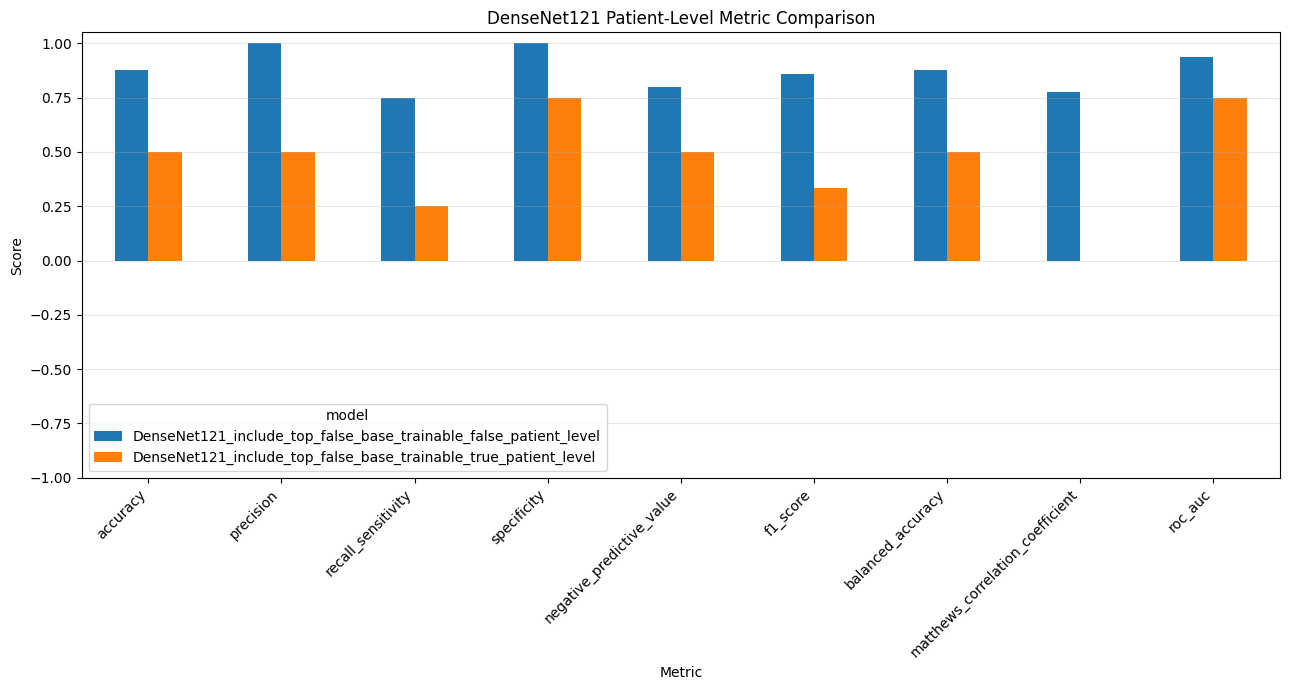

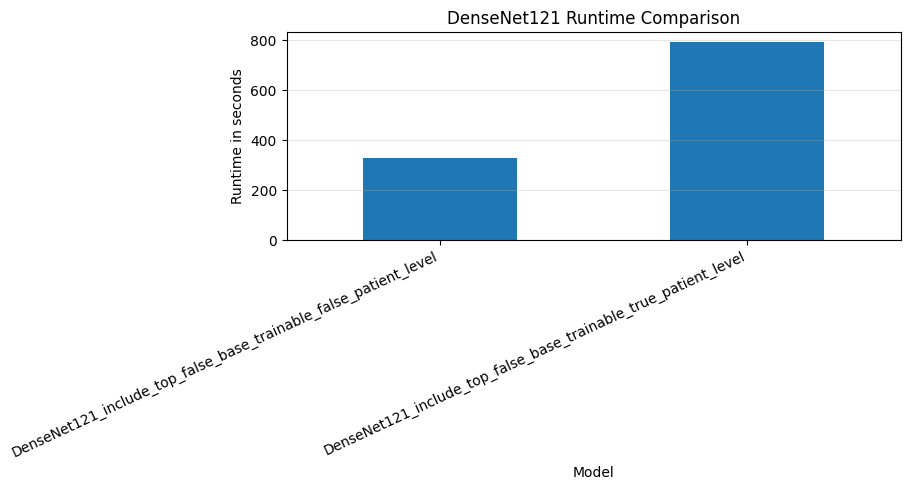

In [16]:
comparison_metrics = pd.DataFrame(
    [
        frozen_result["metrics"],
        trainable_result["metrics"],
    ]
)

comparison_metrics.to_csv(
    REPORT_DIR
    / "densenet121_patient_level_model_comparison.csv",
    index=False,
)

display(comparison_metrics)


metric_columns = [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "negative_predictive_value",
    "f1_score",
    "balanced_accuracy",
    "matthews_correlation_coefficient",
    "roc_auc",
]

metric_plot_df = (
    comparison_metrics[
        ["model"] + metric_columns
    ]
    .set_index("model")
    .T
)

plt.figure(figsize=(13, 7))
metric_plot_df.plot(
    kind="bar",
    ax=plt.gca(),
)
plt.title(
    "DenseNet121 Patient-Level Metric Comparison"
)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(-1.0, 1.05)
plt.xticks(
    rotation=45,
    ha="right",
)
plt.grid(
    axis="y",
    alpha=0.3,
)
plt.tight_layout()

metrics_comparison_graph = (
    GRAPH_DIR
    / "densenet121_all_metrics_comparison.png"
)

plt.savefig(
    metrics_comparison_graph,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close()


runtime_plot_df = comparison_metrics[
    ["model", "runtime_seconds"]
].set_index("model")

plt.figure(figsize=(9, 5))
runtime_plot_df.plot(
    kind="bar",
    ax=plt.gca(),
    legend=False,
)
plt.title("DenseNet121 Runtime Comparison")
plt.xlabel("Model")
plt.ylabel("Runtime in seconds")
plt.xticks(
    rotation=25,
    ha="right",
)
plt.grid(
    axis="y",
    alpha=0.3,
)
plt.tight_layout()

runtime_graph = (
    GRAPH_DIR
    / "densenet121_runtime_comparison.png"
)

plt.savefig(
    runtime_graph,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close()

## 15. Combined patient-level ROC graph and comparison NPZ

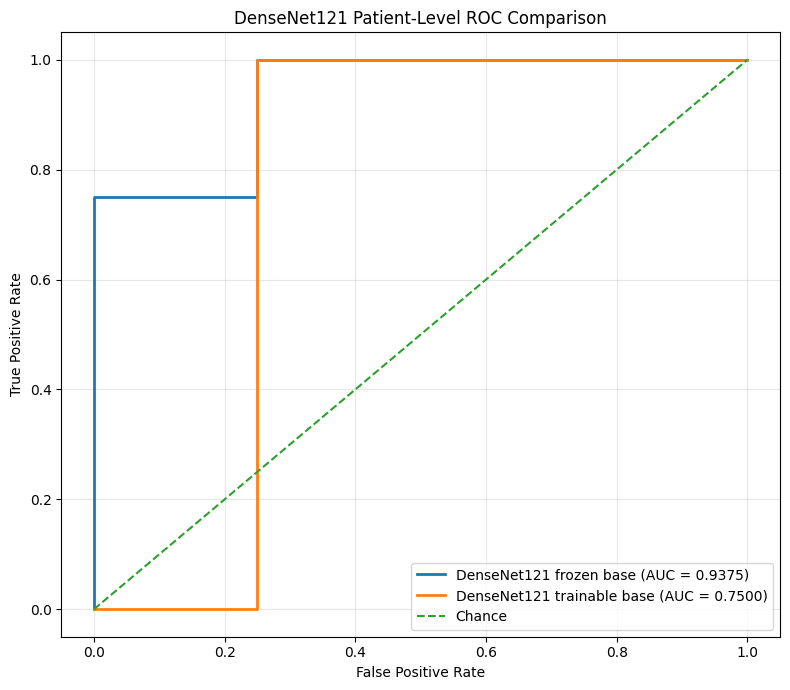

Saved comparison graph: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/densenet121_patient_level_roc_comparison.png
Saved comparison NPZ: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/roc_npz/densenet121_patient_level_roc_comparison.npz


In [17]:
frozen_roc_path = (
    ROC_DIR
    / "densenet121_base_frozen_patient_level_roc.npz"
)
trainable_roc_path = (
    ROC_DIR
    / "densenet121_base_trainable_patient_level_roc.npz"
)


with np.load(
    frozen_roc_path,
    allow_pickle=False,
) as frozen_roc:
    frozen_patient_ids = frozen_roc[
        "patient_ids"
    ]
    frozen_y_true = frozen_roc["y_true"]
    frozen_y_score = frozen_roc["y_score"]
    frozen_fpr = frozen_roc["fpr"]
    frozen_tpr = frozen_roc["tpr"]
    frozen_thresholds = frozen_roc["thresholds"]
    frozen_auc = float(frozen_roc["auc"])


with np.load(
    trainable_roc_path,
    allow_pickle=False,
) as trainable_roc:
    trainable_patient_ids = trainable_roc[
        "patient_ids"
    ]
    trainable_y_true = trainable_roc["y_true"]
    trainable_y_score = trainable_roc["y_score"]
    trainable_fpr = trainable_roc["fpr"]
    trainable_tpr = trainable_roc["tpr"]
    trainable_thresholds = trainable_roc[
        "thresholds"
    ]
    trainable_auc = float(trainable_roc["auc"])


assert np.array_equal(
    frozen_patient_ids,
    trainable_patient_ids,
)
assert np.array_equal(
    frozen_y_true,
    trainable_y_true,
)


plt.figure(figsize=(8, 7))

plt.plot(
    frozen_fpr,
    frozen_tpr,
    linewidth=2,
    label=(
        "DenseNet121 frozen base "
        f"(AUC = {frozen_auc:.4f})"
    ),
)

plt.plot(
    trainable_fpr,
    trainable_tpr,
    linewidth=2,
    label=(
        "DenseNet121 trainable base "
        f"(AUC = {trainable_auc:.4f})"
    ),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance",
)

plt.title(
    "DenseNet121 Patient-Level ROC Comparison"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

combined_roc_graph = (
    GRAPH_DIR
    / "densenet121_patient_level_roc_comparison.png"
)

plt.savefig(
    combined_roc_graph,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close()


comparison_npz_path = (
    ROC_DIR
    / "densenet121_patient_level_roc_comparison.npz"
)

np.savez_compressed(
    comparison_npz_path,
    patient_ids=frozen_patient_ids,
    y_true=frozen_y_true,
    frozen_y_score=frozen_y_score,
    frozen_fpr=frozen_fpr,
    frozen_tpr=frozen_tpr,
    frozen_thresholds=frozen_thresholds,
    frozen_auc=np.asarray(
        frozen_auc,
        dtype=np.float64,
    ),
    trainable_y_score=trainable_y_score,
    trainable_fpr=trainable_fpr,
    trainable_tpr=trainable_tpr,
    trainable_thresholds=trainable_thresholds,
    trainable_auc=np.asarray(
        trainable_auc,
        dtype=np.float64,
    ),
    aggregation=np.asarray(
        PATIENT_AGGREGATION
    ),
    evaluation_level=np.asarray(
        "patient"
    ),
    positive_class=np.asarray(
        "parkinson_dataset"
    ),
    negative_class=np.asarray(
        "healthy_dataset"
    ),
)

print("Saved comparison graph:", combined_roc_graph)
print("Saved comparison NPZ:", comparison_npz_path)

## 16. Compare epoch histories from both models

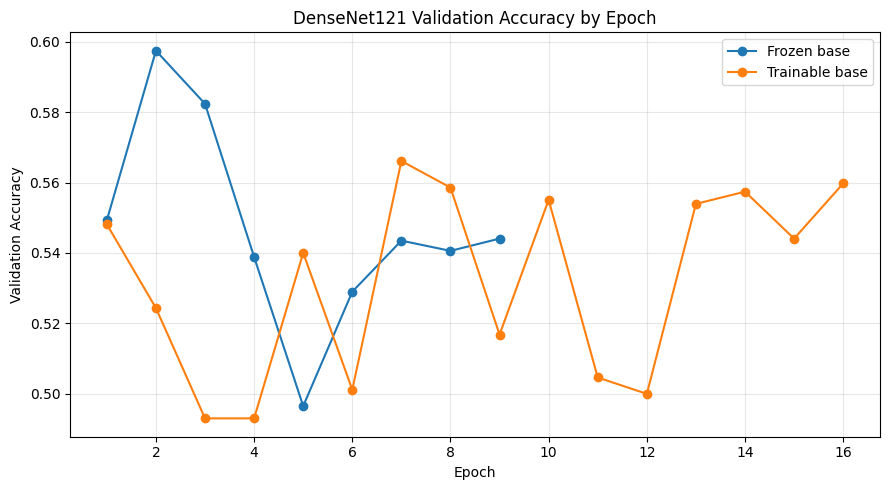

Saved: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/densenet121_validation_accuracy_comparison.png


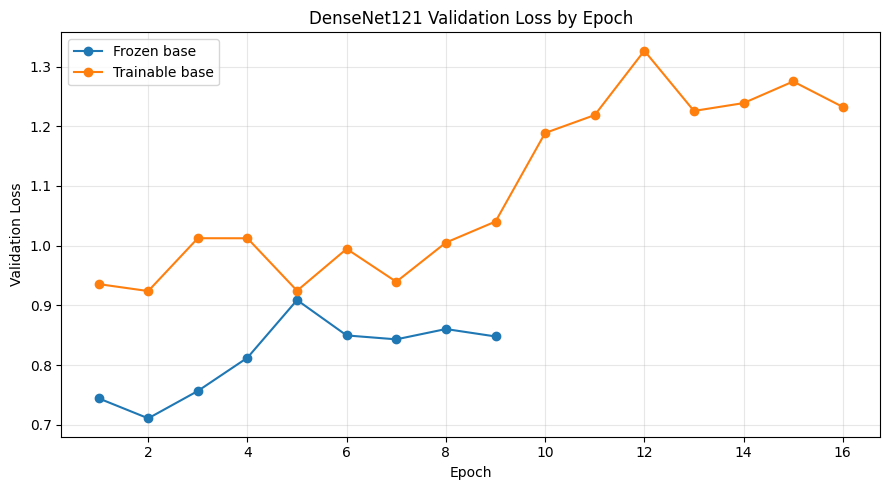

Saved: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/densenet121_validation_loss_comparison.png


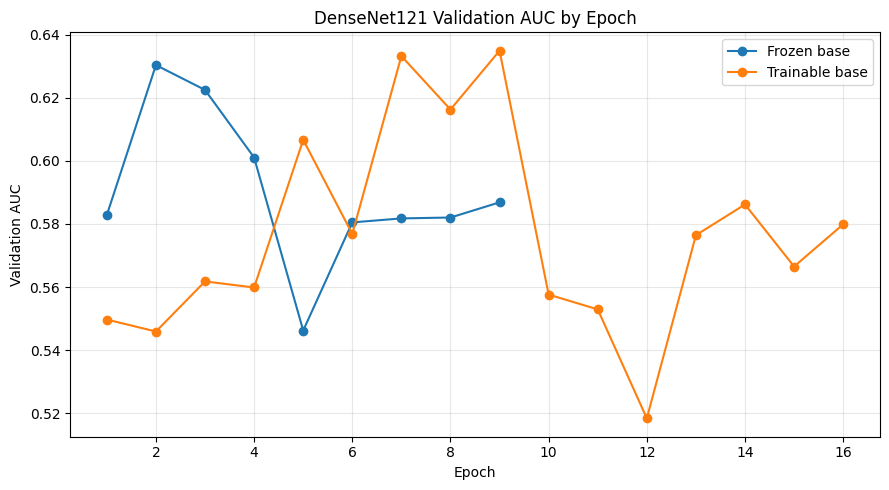

Saved: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/graphs/densenet121_validation_auc_comparison.png


In [18]:
history_comparisons = [
    (
        "val_accuracy",
        "Validation Accuracy",
        "validation_accuracy_comparison",
    ),
    (
        "val_loss",
        "Validation Loss",
        "validation_loss_comparison",
    ),
    (
        "val_auc",
        "Validation AUC",
        "validation_auc_comparison",
    ),
]

for metric_key, display_name, output_name in history_comparisons:
    plt.figure(figsize=(9, 5))

    if metric_key in frozen_result["history"].columns:
        plt.plot(
            frozen_result["history"].index,
            frozen_result["history"][metric_key],
            marker="o",
            label="Frozen base",
        )

    if metric_key in trainable_result["history"].columns:
        plt.plot(
            trainable_result["history"].index,
            trainable_result["history"][metric_key],
            marker="o",
            label="Trainable base",
        )

    plt.title(
        f"DenseNet121 {display_name} by Epoch"
    )
    plt.xlabel("Epoch")
    plt.ylabel(display_name)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    graph_path = (
        GRAPH_DIR
        / f"densenet121_{output_name}.png"
    )

    plt.savefig(
        graph_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    print("Saved:", graph_path)

## 17. Verify every ROC NPZ file

In [19]:
roc_files = [
    ROC_DIR
    / "densenet121_base_frozen_patient_level_roc.npz",
    ROC_DIR
    / "densenet121_base_trainable_patient_level_roc.npz",
    ROC_DIR
    / "densenet121_patient_level_roc_comparison.npz",
]

for roc_file in roc_files:
    print("\nFILE:", roc_file.name)

    with np.load(
        roc_file,
        allow_pickle=False,
    ) as roc_data:
        print("Keys:", roc_data.files)

        for key in roc_data.files:
            value = roc_data[key]
            print(
                f"  {key}: "
                f"shape={value.shape}, "
                f"dtype={value.dtype}"
            )


FILE: densenet121_base_frozen_patient_level_roc.npz
Keys: ['patient_ids', 'y_true', 'y_score', 'y_pred', 'fpr', 'tpr', 'thresholds', 'auc', 'decision_threshold', 'aggregation', 'evaluation_level', 'positive_class', 'negative_class', 'model_name', 'number_of_images']
  patient_ids: shape=(8,), dtype=<U6
  y_true: shape=(8,), dtype=int64
  y_score: shape=(8,), dtype=float64
  y_pred: shape=(8,), dtype=int64
  fpr: shape=(6,), dtype=float64
  tpr: shape=(6,), dtype=float64
  thresholds: shape=(6,), dtype=float64
  auc: shape=(), dtype=float64
  decision_threshold: shape=(), dtype=float64
  aggregation: shape=(), dtype=<U4
  evaluation_level: shape=(), dtype=<U7
  positive_class: shape=(), dtype=<U17
  negative_class: shape=(), dtype=<U15
  model_name: shape=(), dtype=<U64
  number_of_images: shape=(8,), dtype=int64

FILE: densenet121_base_trainable_patient_level_roc.npz
Keys: ['patient_ids', 'y_true', 'y_score', 'y_pred', 'fpr', 'tpr', 'thresholds', 'auc', 'decision_threshold', 'aggregat

## 18. Show all saved files

In [20]:
for directory_name, directory_path in [
    ("Models", MODEL_DIR),
    ("History", HISTORY_DIR),
    ("Graphs", GRAPH_DIR),
    ("Confusion matrices", CM_DIR),
    ("Reports", REPORT_DIR),
    ("ROC NPZ", ROC_DIR),
    ("Predictions", PREDICTION_DIR),
    ("Patient splits", SPLIT_DIR),
    ("Grad-CAM", GRADCAM_DIR),
]:
    print(
        f"\n{directory_name}: "
        f"{directory_path}"
    )

    for saved_file in sorted(
        directory_path.iterdir()
    ):
        print("  -", saved_file.name)


Models: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/models
  - DenseNet121_include_top_false_base_trainable_false_patient_level_best.keras
  - DenseNet121_include_top_false_base_trainable_false_patient_level_final.keras
  - DenseNet121_include_top_false_base_trainable_true_patient_level_best.keras
  - DenseNet121_include_top_false_base_trainable_true_patient_level_final.keras

History: /content/drive/MyDrive/Patient_level_classification/densenet_single_model_data_save_here/history
  - DenseNet121_include_top_false_base_trainable_false_patient_level_epoch_log.csv
  - DenseNet121_include_top_false_base_trainable_false_patient_level_history.csv
  - DenseNet121_include_top_false_base_trainable_false_patient_level_history.json
  - DenseNet121_include_top_false_base_trainable_true_patient_level_epoch_log.csv
  - DenseNet121_include_top_false_base_trainable_true_patient_level_history.csv
  - DenseNet121_include_top_false_base_trainable_true_patien

## 19. Create a downloadable results ZIP

In [21]:
# By default, this creates a smaller package without the large .keras files.
# Change INCLUDE_MODELS_IN_ZIP=True to include trained models.

INCLUDE_MODELS_IN_ZIP = False

package_directory = Path(
    "/content/densenet121_patient_level_package"
)

if package_directory.exists():
    shutil.rmtree(package_directory)

package_directory.mkdir(
    parents=True,
    exist_ok=True,
)


small_result_directories = [
    HISTORY_DIR,
    GRAPH_DIR,
    CM_DIR,
    REPORT_DIR,
    ROC_DIR,
    PREDICTION_DIR,
    SPLIT_DIR,
    GRADCAM_DIR,
]

for source_directory in small_result_directories:
    destination_directory = (
        package_directory
        / source_directory.name
    )

    shutil.copytree(
        source_directory,
        destination_directory,
        dirs_exist_ok=True,
    )


if INCLUDE_MODELS_IN_ZIP:
    shutil.copytree(
        MODEL_DIR,
        package_directory / MODEL_DIR.name,
        dirs_exist_ok=True,
    )


zip_base_path = (
    "/content/"
    "DenseNet121_patient_level_results"
)

zip_path = shutil.make_archive(
    zip_base_path,
    "zip",
    root_dir=package_directory,
)

print("Created ZIP:", zip_path)

Created ZIP: /content/DenseNet121_patient_level_results.zip


In [22]:
from google.colab import files

files.download(
    "/content/"
    "DenseNet121_patient_level_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final interpretation

- The models train on 2D MRI slices.
- The dataset is split using unique patient IDs before any model training.
- All slices from one patient stay in one split.
- Test slice probabilities are combined into one probability per patient.
- The final confusion matrices, classification reports, ROC curves, ROC-AUC,
  accuracy, precision, recall, specificity and F1-score are patient-level results.
- Actual models, graphs and `.npz` values are created only after the notebook
  is run on the MRI dataset.
- Grad-CAM uses only representative patient-level test images and is saved as both PNG and raw `.npz` data.